# Sleep, Cerebral Protein Synthesis, and Visual Memory Consolidation Using [¹¹C]Leucine PET

## Project overview

This independent Python neuroimaging project reanalyses OpenNeuro dataset **ds004731 v1.0.0**, *Rates of cerebral protein synthesis and memory formation during sleep*. The source experiment used visual texture-discrimination training followed by sleep or wakefulness and L-[1-¹¹C]leucine PET-derived rates of cerebral protein synthesis (rCPS).

### Primary objective

The central question is whether PET-derived cerebral protein synthesis provides evidence consistent with **sleep-dependent consolidation of a trained visual representation**. The analysis therefore moves from the PET acquisition itself to three linked tests:

1. **Global sleep/wake effect:** does cortical rCPS differ between participants who slept and those who remained awake?
2. **Training-specific V1 effect:** is rCPS higher in V1 contralateral to the trained visual field than in the untrained hemisphere?
3. **Sleep modulation of training-related V1 rCPS:** is the trained–untrained V1 difference larger after sleep, and does it covary with Stage 3 sleep?

A whole-cortex regional analysis complements these targeted tests by asking whether sleep-related rCPS differences are spatially distributed beyond V1.

### Computational objective

A second aim is to build an end-to-end Python workflow for PET/neuroimaging data: NIfTI inspection, dynamic PET visualisation, FreeSurfer/fsaverage surface handling, atlas parcellation, QC, cohort aggregation, statistical inference, multiple-comparison correction, permutation testing, and reproducible GitHub documentation.

> **Scope.** Memory consolidation is the biological motivation, but behavioural performance is not modelled directly in this notebook. The analyses test molecular/neuroimaging signatures relevant to consolidation; they do not establish that memory itself improved or worsened.


In [1]:
from pathlib import Path
import json
import gzip
import shutil

import nibabel as nib
import nibabel.freesurfer.io as fsio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

print("Environment ready")

Environment ready


In [2]:
# Project directories
# Keep the notebook in the repository root when running locally.
project_dir = Path.cwd()

data_dir = project_dir / "data"
figures_dir = project_dir / "figures"
results_dir = project_dir / "results"
annotations_dir = project_dir / "annotations"

figures_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)
annotations_dir.mkdir(exist_ok=True)

print("Project:", project_dir)
print("Data:", data_dir)
print("Figures:", figures_dir)
print("Results:", results_dir)


Project: C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub
Data: C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub\data
Figures: C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub\figures
Results: C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub\results


## Dataset and analysis inputs

The analysis uses OpenNeuro ds004731 PET data and derived rCPS maps. Raw dynamic PET is visualised first, followed by volumetric and surface-derived rCPS analyses.


## 1. Dynamic PET acquisition

The raw L-[1-¹¹C]leucine acquisition is a 4D PET time series. Representative frames are shown first to connect the later quantitative rCPS maps to the underlying dynamic measurement.


In [3]:
# Locate a representative raw 4D PET acquisition.
# Preferred GitHub layout: data/raw/<file>. A Downloads fallback keeps the
# notebook convenient on the machine used for the original analysis.
dynamic_candidates = list(data_dir.rglob("sub-SM07_ses-Awake_pet.nii.gz"))

downloads_dynamic = Path.home() / "Downloads" / "sub-SM07_ses-Awake_pet.nii.gz"
if downloads_dynamic.exists():
    dynamic_candidates.append(downloads_dynamic)

if not dynamic_candidates:
    raise FileNotFoundError(
        "Could not find sub-SM07_ses-Awake_pet.nii.gz. "
        "Download it from OpenNeuro ds004731 and place it under data/."
    )

dynamic_pet_path = dynamic_candidates[0]
pet_img = nib.load(dynamic_pet_path)

print("Dynamic PET:", dynamic_pet_path)
print("Shape:", pet_img.shape)
print("Frames:", pet_img.shape[3])


Dynamic PET: C:\Users\asus\Downloads\sub-SM07_ses-Awake_pet.nii.gz
Shape: (256, 203, 256, 42)
Frames: 42


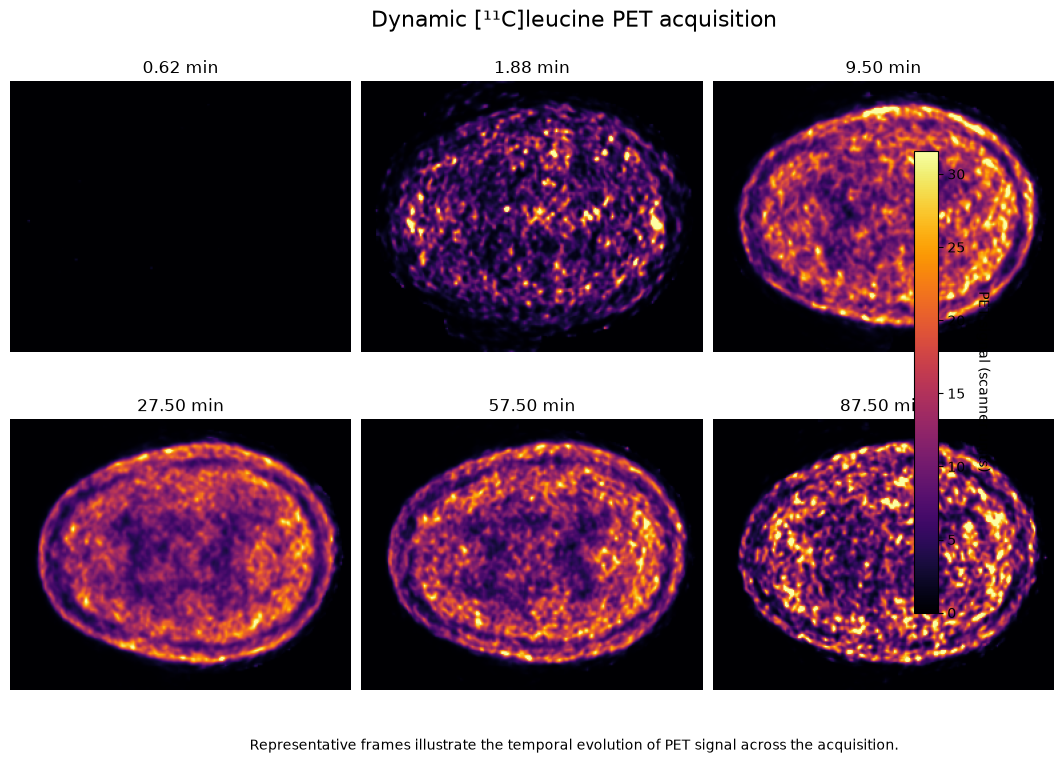

In [4]:
# FINAL DYNAMIC PET FIGURE
# Representative evolution of [11C]leucine PET signal over time

import numpy as np
import matplotlib.pyplot as plt

selected_frames = [2, 7, 23, 29, 35, 41]
selected_times = [0.62, 1.88, 9.50, 27.50, 57.50, 87.50]

# Pick a useful axial slice
z = pet_img.shape[2] // 2

# Load selected frames only
frames = [
    np.asarray(pet_img.dataobj[:, :, z, frame])
    for frame in selected_frames
]

# Use ONE display scale across all six frames
all_values = np.concatenate([
    frame[np.isfinite(frame) & (frame > 0)]
    for frame in frames
])

vmin = 0
vmax = np.percentile(all_values, 99)

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8)
)

for ax, frame_data, time in zip(
    axes.flat,
    frames,
    selected_times
):

    im = ax.imshow(
        np.rot90(frame_data),
        cmap="inferno",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f"{time:.2f} min",
        fontsize=12
    )

    ax.axis("off")

fig.suptitle(
    "Dynamic [¹¹C]leucine PET acquisition",
    fontsize=16,
    y=0.96
)

# Shared colour bar
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.75,
    pad=0.02
)

cbar.set_label(
    "PET signal (scanner units)",
    rotation=270,
    labelpad=18
)

fig.text(
    0.5,
    0.035,
    "Representative frames illustrate the temporal evolution "
    "of PET signal across the acquisition.",
    ha="center",
    fontsize=10
)

plt.subplots_adjust(
    left=0.03,
    right=0.90,
    bottom=0.09,
    top=0.89,
    wspace=0.03,
    hspace=0.12
)

plt.savefig(
    figures_dir / "dynamic_pet_timecourse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2. Volumetric rCPS inspection

A representative voxelwise rCPS derivative was inspected in anatomical planes. Percentile-based display limits are used only for visualisation; the underlying data are not clipped.


In [5]:
# Locate a representative volumetric rCPS derivative.
rcps_candidates = list(
    data_dir.rglob("sub-SM07_ses-Awake_desc-ArtIF_stat-rCPS_statmap.nii.gz")
)

downloads_rcps = (
    Path.home() / "Downloads" /
    "sub-SM07_ses-Awake_desc-ArtIF_stat-rCPS_statmap.nii.gz"
)
if downloads_rcps.exists():
    rcps_candidates.append(downloads_rcps)

if not rcps_candidates:
    raise FileNotFoundError(
        "Could not find the SM07 volumetric rCPS derivative. "
        "Place the OpenNeuro ds004731 derivative under data/."
    )

rcps_path = rcps_candidates[0]
rcps_img = nib.load(rcps_path)

print("rCPS volume:", rcps_path)
print("Shape:", rcps_img.shape)
print("Orientation:", nib.aff2axcodes(rcps_img.affine))


rCPS volume: C:\Users\asus\Downloads\sub-SM07_ses-Awake_desc-ArtIF_stat-rCPS_statmap.nii.gz
Shape: (256, 203, 256)
Orientation: ('P', 'R', 'S')


Display range: 0.15 to 2.95 nmol/g/min


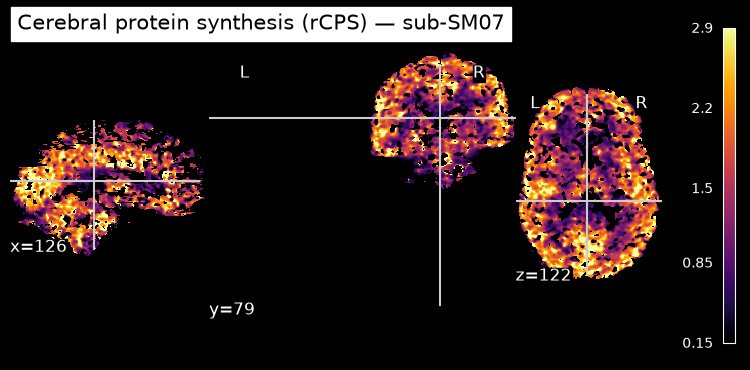

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting

# Get voxel values
rcps_data = rcps_img.get_fdata()

# Positive finite voxels only
positive = rcps_data[
    np.isfinite(rcps_data) & (rcps_data > 0)
]

# Robust display range
vmin_vol = np.percentile(positive, 5)
vmax_vol = np.percentile(positive, 95)

print(
    "Display range:",
    round(vmin_vol, 2),
    "to",
    round(vmax_vol, 2),
    "nmol/g/min"
)

display = plotting.plot_stat_map(
    rcps_img,
    display_mode="ortho",
    cmap="inferno",
    black_bg=True,
    threshold=vmin_vol,
    vmin=vmin_vol,
    vmax=vmax_vol,
    colorbar=True,
    title="Cerebral protein synthesis (rCPS) — sub-SM07"
)

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_31760\1693886371.py:4: UserWarning: A non-diagonal affine is found in the given image. Reordering the image to get diagonal affine for finding cuts in the slices.
  display = plotting.plot_stat_map(


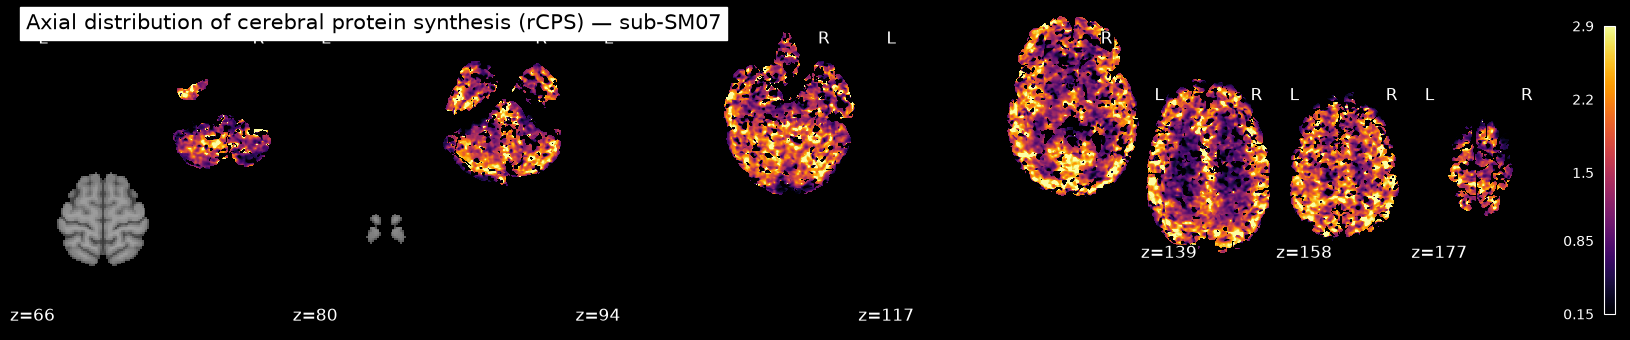

In [7]:
from nilearn import plotting
import matplotlib.pyplot as plt

display = plotting.plot_stat_map(
    rcps_img,
    display_mode="z",
    cut_coords=7,
    cmap="inferno",
    black_bg=True,
    threshold=vmin_vol,
    vmin=vmin_vol,
    vmax=vmax_vol,
    colorbar=True,
    title="Axial distribution of cerebral protein synthesis (rCPS) — sub-SM07"
)

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_31760\4150059484.py:1: UserWarning: A non-diagonal affine is found in the given image. Reordering the image to get diagonal affine for finding cuts in the slices.
  display = plotting.plot_stat_map(


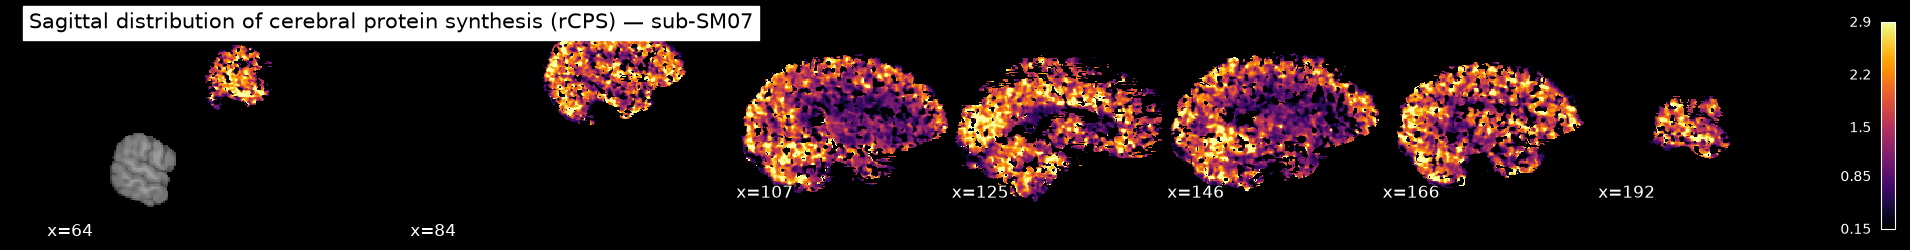

In [8]:
display = plotting.plot_stat_map(
    rcps_img,
    display_mode="x",
    cut_coords=7,
    cmap="inferno",
    black_bg=True,
    threshold=vmin_vol,
    vmin=vmin_vol,
    vmax=vmax_vol,
    colorbar=True,
    title="Sagittal distribution of cerebral protein synthesis (rCPS) — sub-SM07"
)

plt.show()

## 3. Surface rCPS quality control

The primary cohort analysis uses fsaverage surface rCPS derivatives. A representative participant is inspected before regional parcellation and cohort aggregation.


In [9]:
# Example participant used for initial inspection
participant = "sub-SM07"
session = "ses-Awake"

participant_dir = data_dir / participant

lh_path = (
    participant_dir /
    f"{participant}_{session}_space-fsaverage_pvc-nopvc_hemi-lh_desc-ArtIF_rcps.nii.gz"
)

rh_path = (
    participant_dir /
    f"{participant}_{session}_space-fsaverage_pvc-nopvc_hemi-rh_desc-ArtIF_rcps.nii.gz"
)

print("Left hemisphere file exists:", lh_path.exists())
print("Right hemisphere file exists:", rh_path.exists())

Left hemisphere file exists: True
Right hemisphere file exists: True


In [10]:
lh_img = nib.load(lh_path)
rh_img = nib.load(rh_path)

lh_rcps = np.asarray(lh_img.dataobj).squeeze()
rh_rcps = np.asarray(rh_img.dataobj).squeeze()

print("Left hemisphere")
print("----------------")
print("Shape:", lh_rcps.shape)
print("Finite vertices:", np.isfinite(lh_rcps).sum())
print("Mean rCPS:", np.nanmean(lh_rcps))
print("Range:", np.nanmin(lh_rcps), "to", np.nanmax(lh_rcps))

print("\nRight hemisphere")
print("----------------")
print("Shape:", rh_rcps.shape)
print("Finite vertices:", np.isfinite(rh_rcps).sum())
print("Mean rCPS:", np.nanmean(rh_rcps))
print("Range:", np.nanmin(rh_rcps), "to", np.nanmax(rh_rcps))

Left hemisphere
----------------
Shape: (163842,)
Finite vertices: 163842
Mean rCPS: 1.5118012
Range: 0.0 to 26.957943

Right hemisphere
----------------
Shape: (163842,)
Finite vertices: 163842
Mean rCPS: 1.4810138
Range: 0.0 to 27.64667


In [11]:
# Basic signal QC for the example participant

for hemisphere, rcps in [
    ("Left", lh_rcps),
    ("Right", rh_rcps)
]:
    positive = rcps[np.isfinite(rcps) & (rcps > 0)]

    print(f"{hemisphere} hemisphere")
    print("-" * 30)
    print("Total vertices:", len(rcps))
    print("Positive vertices:", len(positive))
    print("Zero vertices:", np.sum(rcps == 0))
    print("Median positive rCPS:", np.median(positive))
    print("Mean positive rCPS:", np.mean(positive))
    print()

Left hemisphere
------------------------------
Total vertices: 163842
Positive vertices: 137397
Zero vertices: 26445
Median positive rCPS: 1.8162782
Mean positive rCPS: 1.8027798

Right hemisphere
------------------------------
Total vertices: 163842
Positive vertices: 134986
Zero vertices: 28856
Median positive rCPS: 1.8206677
Mean positive rCPS: 1.7976106



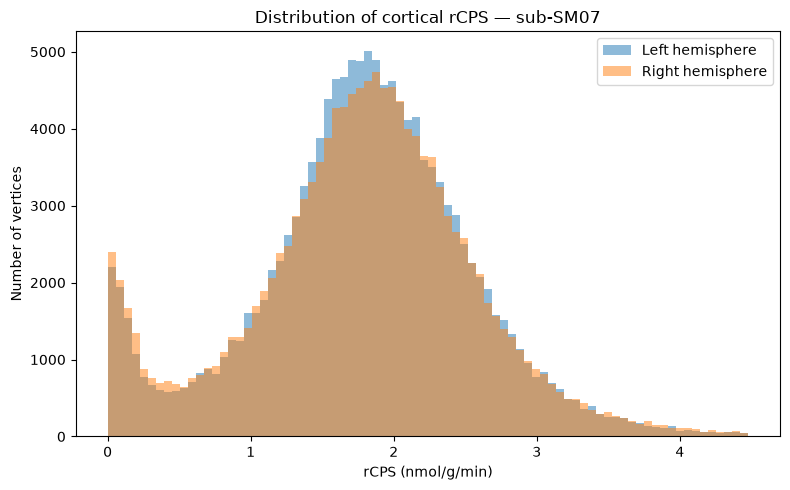

Display limited to 99.5th percentile: 4.48 nmol/g/min


In [12]:
# Distribution of positive cortical rCPS values

lh_positive = lh_rcps[np.isfinite(lh_rcps) & (lh_rcps > 0)]
rh_positive = rh_rcps[np.isfinite(rh_rcps) & (rh_rcps > 0)]

# Display range based on the combined 99.5th percentile
combined = np.concatenate([lh_positive, rh_positive])
display_max = np.percentile(combined, 99.5)

plt.figure(figsize=(8, 5))

plt.hist(
    lh_positive,
    bins=80,
    range=(0, display_max),
    alpha=0.5,
    label="Left hemisphere"
)

plt.hist(
    rh_positive,
    bins=80,
    range=(0, display_max),
    alpha=0.5,
    label="Right hemisphere"
)

plt.xlabel("rCPS (nmol/g/min)")
plt.ylabel("Number of vertices")
plt.title("Distribution of cortical rCPS — sub-SM07")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Display limited to 99.5th percentile: {display_max:.2f} nmol/g/min")

The distribution of positive cortical rCPS values was inspected as an initial quality-control step. Left- and right-hemisphere distributions showed substantial overlap in the example participant. The histogram is displayed to the 99.5th percentile to prevent a small number of high-intensity vertices from obscuring the central distribution; no values were removed from subsequent analyses on the basis of this visualisation.

## 4. Cortical parcellation and regional rCPS extraction


### Surface-space compatibility check

Exploratory work identified a Destrieux annotation/PET vertex mismatch (approximately 168k versus 163,842 vertices per hemisphere). Direct vertex-wise indexing is only valid when PET and atlas data share the same surface mesh, so those mismatched annotations were discarded.

The analysis below therefore uses Destrieux `aparc.a2009s` annotations defined on the FreeSurfer `fsaverage` surface. Compatibility is explicitly checked before regional extraction.


In [13]:
# Atlas files are kept in the repository's annotations/ directory.
# They are not generated by this notebook; see README for setup instructions.
print("Annotation directory:", annotations_dir)


Annotation directory: C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub\annotations


In [14]:
from nibabel.freesurfer.io import read_annot

# FreeSurfer fsaverage Destrieux annotations used for surface parcellation.
# Expected repository layout: annotations/lh.aparc.a2009s.annot and rh.aparc.a2009s.annot
fsavg_annot_dir = annotations_dir

fsavg_lh_annot = fsavg_annot_dir / "lh.aparc.a2009s.annot"
fsavg_rh_annot = fsavg_annot_dir / "rh.aparc.a2009s.annot"

print("LH annotation exists:", fsavg_lh_annot.exists())
print("RH annotation exists:", fsavg_rh_annot.exists())


LH annotation exists: True
RH annotation exists: True


In [15]:
# Load Destrieux annotations in fsaverage space

fsavg_lh_path = fsavg_annot_dir / "lh.aparc.a2009s.annot"
fsavg_rh_path = fsavg_annot_dir / "rh.aparc.a2009s.annot"

fsavg_lh_labels, fsavg_lh_ctab, fsavg_lh_names = read_annot(fsavg_lh_path)
fsavg_rh_labels, fsavg_rh_ctab, fsavg_rh_names = read_annot(fsavg_rh_path)

fsavg_lh_names = [name.decode("utf-8") for name in fsavg_lh_names]
fsavg_rh_names = [name.decode("utf-8") for name in fsavg_rh_names]

print("PET LH vertices:  ", len(lh_rcps))
print("Atlas LH vertices:", len(fsavg_lh_labels))

print("\nPET RH vertices:  ", len(rh_rcps))
print("Atlas RH vertices:", len(fsavg_rh_labels))

print("\nLH atlas regions:", len(fsavg_lh_names))
print("RH atlas regions:", len(fsavg_rh_names))

PET LH vertices:   163842
Atlas LH vertices: 163842

PET RH vertices:   163842
Atlas RH vertices: 163842

LH atlas regions: 76
RH atlas regions: 76


In [16]:
from pathlib import Path
from nibabel.freesurfer.io import read_annot

other_dir = Path.home() / "PET_memory_project" / "fsaverage_annotations"

for hemi in ["lh", "rh"]:
    path = other_dir / f"{hemi}.aparc.a2009s.annot"
    labels, ctab, names = read_annot(path)

    print(
        hemi.upper(),
        "| vertices:", len(labels),
        "| regions:", len(names)
    )

LH | vertices: 163842 | regions: 76
RH | vertices: 163842 | regions: 76


In [17]:
lh_aligned = len(lh_rcps) == len(fsavg_lh_labels)
rh_aligned = len(rh_rcps) == len(fsavg_rh_labels)

print("LH PET ↔ atlas aligned:", lh_aligned)
print("RH PET ↔ atlas aligned:", rh_aligned)

if lh_aligned and rh_aligned:
    print("\n✓ Surface-space compatibility confirmed.")
else:
    print("\n✗ Surface-space mismatch — do not perform vertex-wise extraction.")

LH PET ↔ atlas aligned: True
RH PET ↔ atlas aligned: True

✓ Surface-space compatibility confirmed.


### Regional rCPS extraction

Following confirmation of surface-space compatibility, vertex-level rCPS values were grouped according to the Destrieux cortical parcellation.

For each cortical region and hemisphere, the mean rCPS was calculated from finite, positive-valued vertices. Regional coverage was defined as the proportion of atlas vertices containing valid rCPS signal. Retaining coverage information allowed regional estimates with insufficient PET sampling to be identified during subsequent quality control.

In [18]:
def extract_regional_rcps(rcps, labels, names, hemisphere):
    """
    Extract regional mean rCPS and signal coverage from a
    surface-based PET derivative and matching atlas annotation.
    """
    
    rows = []

    for label_id, region_name in enumerate(names):

        # Exclude non-anatomical atlas label
        if region_name.lower() == "unknown":
            continue

        region_mask = labels == label_id
        n_vertices = region_mask.sum()

        if n_vertices == 0:
            continue

        region_values = rcps[region_mask]

        valid = np.isfinite(region_values) & (region_values > 0)
        n_valid = valid.sum()

        coverage = n_valid / n_vertices

        mean_rcps = (
            np.mean(region_values[valid])
            if n_valid > 0
            else np.nan
        )

        rows.append({
            "hemisphere": hemisphere,
            "region": region_name,
            "n_vertices": n_vertices,
            "n_valid": n_valid,
            "coverage": coverage,
            "mean_rcps": mean_rcps
        })

    return pd.DataFrame(rows)

In [19]:
sm07_lh_regions = extract_regional_rcps(
    lh_rcps,
    fsavg_lh_labels,
    fsavg_lh_names,
    "left"
)

sm07_rh_regions = extract_regional_rcps(
    rh_rcps,
    fsavg_rh_labels,
    fsavg_rh_names,
    "right"
)

sm07_regions = pd.concat(
    [sm07_lh_regions, sm07_rh_regions],
    ignore_index=True
)

print("Regional measurements:", len(sm07_regions))
print("\nRegions per hemisphere:")
print(sm07_regions.groupby("hemisphere").size())

sm07_regions.head(10)

Regional measurements: 148

Regions per hemisphere:
hemisphere
left     74
right    74
dtype: int64


,hemisphere,region,n_vertices,n_valid,coverage,mean_rcps
0,left,G_and_S_frontomargin,932,522,0.560086,1.736119
1,left,G_and_S_occipital_inf,1277,1237,0.968677,1.903861
2,left,G_and_S_paracentral,2272,1679,0.738996,1.649857
3,left,G_and_S_subcentral,2607,2431,0.932489,1.861235
4,left,G_and_S_transv_frontopol,627,325,0.518341,1.864577
5,left,G_and_S_cingul-Ant,2171,2017,0.929065,1.524171
6,left,G_and_S_cingul-Mid-Ant,1957,1902,0.971896,1.771740
7,left,G_and_S_cingul-Mid-Post,2386,2355,0.987008,1.812755
8,left,G_cingul-Post-dorsal,1098,1074,0.978142,1.703151
9,left,G_cingul-Post-ventral,520,513,0.986538,1.610490


In [20]:
# Regional coverage QC for example participant

coverage_summary = (
    sm07_regions
    .groupby("hemisphere")["coverage"]
    .describe()
)

coverage_summary

,count,mean,std,min,25%,50%,75%,max
hemisphere,,,,,,,,
left,74.0,0.909403,0.120026,0.300397,0.895875,0.95665,0.973322,1.000000
right,74.0,0.888517,0.141528,0.258510,0.892494,0.93259,0.962641,0.992408


In [21]:
# Regions with the lowest PET coverage

sm07_regions[
    ["hemisphere", "region", "coverage", "mean_rcps"]
].sort_values("coverage").head(15)

,hemisphere,region,coverage,mean_rcps
97,right,G_orbital,0.258510,1.366659
23,left,G_orbital,0.300397,1.652865
137,right,S_orbital-H_Shaped,0.414182,1.407477
74,right,G_and_S_frontomargin,0.414286,1.603284
86,right,G_front_inf-Orbital,0.513889,2.344517
4,left,G_and_S_transv_frontopol,0.518341,1.864577
0,left,G_and_S_frontomargin,0.560086,1.736119
104,right,G_rectus,0.571888,1.409127
78,right,G_and_S_transv_frontopol,0.587666,1.872432
63,left,S_orbital-H_Shaped,0.615942,1.264277


In [22]:
# Minimum proportion of vertices with positive finite rCPS required
# for a cortical region to pass coverage QC.
COVERAGE_THRESHOLD = 0.80

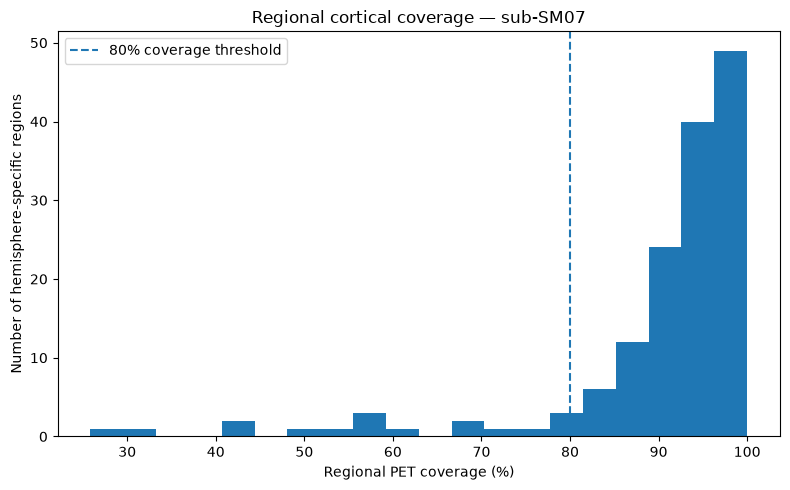

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    sm07_regions["coverage"] * 100,
    bins=20
)

plt.axvline(
    COVERAGE_THRESHOLD * 100,
    linestyle="--",
    label="80% coverage threshold"
)

plt.xlabel("Regional PET coverage (%)")
plt.ylabel("Number of hemisphere-specific regions")
plt.title("Regional cortical coverage — sub-SM07")
plt.legend()

plt.tight_layout()
plt.show()

### Regional coverage criterion

Most cortical parcels showed high PET signal coverage, although a subset of predominantly orbital and frontal regions contained substantially fewer valid vertices.

To reduce the influence of incompletely sampled parcels, regional measurements were considered sufficiently covered when at least 80% of atlas vertices contained finite, positive rCPS values. Coverage was retained as a separate variable so that the impact of this criterion could be quantified rather than treating excluded measurements as valid regional estimates.

In [24]:
sm07_regions["passes_coverage"] = (
    sm07_regions["coverage"] >= COVERAGE_THRESHOLD
)

print("Coverage threshold: 80%")
print(
    "Passing:",
    sm07_regions["passes_coverage"].sum(),
    "of",
    len(sm07_regions)
)

print(
    "Below threshold:",
    (~sm07_regions["passes_coverage"]).sum()
)

Coverage threshold: 80%
Passing: 133 of 148
Below threshold: 15


In [25]:
sm07_regions.loc[
    ~sm07_regions["passes_coverage"],
    ["hemisphere", "region", "coverage"]
].sort_values("coverage")

,hemisphere,region,coverage
97,right,G_orbital,0.258510
23,left,G_orbital,0.300397
137,right,S_orbital-H_Shaped,0.414182
74,right,G_and_S_frontomargin,0.414286
86,right,G_front_inf-Orbital,0.513889
4,left,G_and_S_transv_frontopol,0.518341
0,left,G_and_S_frontomargin,0.560086
104,right,G_rectus,0.571888
78,right,G_and_S_transv_frontopol,0.587666
63,left,S_orbital-H_Shaped,0.615942


In [26]:
participant_dirs = sorted(
    [
        path for path in data_dir.iterdir()
        if path.is_dir() and path.name.startswith("sub-")
    ]
)

print("Participant folders found:", len(participant_dirs))

for path in participant_dirs:
    print(path.name)

Participant folders found: 35
sub-SM07
sub-SM08
sub-SM09
sub-SM10
sub-SM11
sub-SM12
sub-SM16
sub-SM19
sub-SM21
sub-SM22
sub-SM23
sub-SM24
sub-SM27
sub-SM28
sub-SM30
sub-SM31
sub-SM32
sub-SM33
sub-SM35
sub-SM36
sub-SM37
sub-SM38
sub-SM40
sub-SM43
sub-SM45
sub-SM47
sub-SM48
sub-SM50
sub-SM51
sub-SM52
sub-SM54
sub-SM56
sub-SM58
sub-SM60
sub-SM61


In [27]:
import nilearn
print("Nilearn version:", nilearn.__version__)


Nilearn version: 0.14.1


In [28]:
from nilearn import datasets

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage")

print(fsaverage.keys())

[fetch_surf_fsaverage] Dataset directory found: C:\Users\asus\nilearn_data\fsaverage
dict_keys(['area_left', 'area_right', 'curv_left', 'curv_right', 'flat_left', 'flat_right', 'infl_left', 'infl_right', 'pial_left', 'pial_right', 'sphere_left', 'sphere_right', 'sulc_left', 'sulc_right', 'thick_left', 'thick_right', 'white_left', 'white_right', 'description'])


In [29]:
from nilearn import plotting
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

figures_dir = Path.cwd() / "figures"
figures_dir.mkdir(exist_ok=True)

# Display range based on positive cortical rCPS values
all_positive = np.concatenate([
    lh_rcps[lh_rcps > 0],
    rh_rcps[rh_rcps > 0]
])

vmin = np.percentile(all_positive, 5)
vmax = np.percentile(all_positive, 95)

print("Display range:", round(vmin, 2), "to", round(vmax, 2), "nmol/g/min")

Display range: 0.21 to 3.04 nmol/g/min


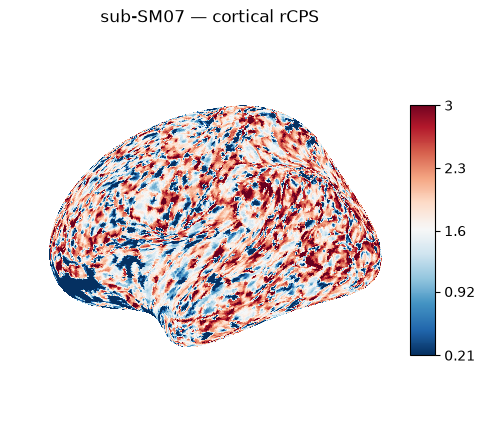

In [30]:
plotting.plot_surf_stat_map(
    fsaverage["infl_left"],
    lh_rcps,
    hemi="left",
    view="lateral",
    bg_map=fsaverage["sulc_left"],
    colorbar=True,
    vmin=vmin,
    vmax=vmax,
    title="sub-SM07 — cortical rCPS"
)

plt.show()

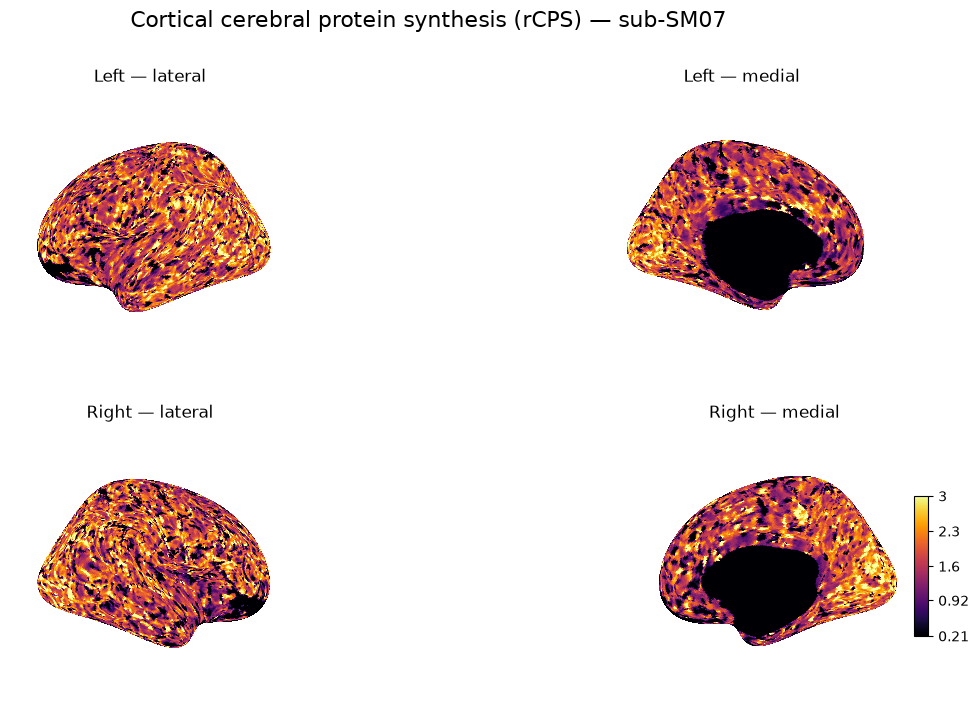

In [31]:
fig = plt.figure(figsize=(14, 8))

views = [
    ("left", "lateral", lh_rcps, fsaverage["infl_left"], fsaverage["sulc_left"]),
    ("left", "medial",  lh_rcps, fsaverage["infl_left"], fsaverage["sulc_left"]),
    ("right", "lateral", rh_rcps, fsaverage["infl_right"], fsaverage["sulc_right"]),
    ("right", "medial",  rh_rcps, fsaverage["infl_right"], fsaverage["sulc_right"]),
]

titles = [
    "Left — lateral",
    "Left — medial",
    "Right — lateral",
    "Right — medial"
]

for i, ((hemi, view, data, mesh, sulc), title) in enumerate(zip(views, titles)):
    
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")

    plotting.plot_surf_stat_map(
        mesh,
        data,
        hemi=hemi,
        view=view,
        bg_map=sulc,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
        colorbar=(i == 3),
        axes=ax,
        title=title
    )

fig.suptitle(
    "Cortical cerebral protein synthesis (rCPS) — sub-SM07",
    fontsize=16
)

plt.savefig(
    figures_dir / "SM07_cortical_rcps_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
fig.savefig(
    figures_dir / "SM07_cortical_rcps_surface.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", figures_dir / "SM07_cortical_rcps_surface.png")


Saved: C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub\figures\SM07_cortical_rcps_surface.png


In [33]:
# Create empty surface maps
lh_regional_map = np.full(len(fsavg_lh_labels), np.nan, dtype=float)
rh_regional_map = np.full(len(fsavg_rh_labels), np.nan, dtype=float)

# LEFT HEMISPHERE
for _, row in sm07_regions[
    (sm07_regions["hemisphere"] == "left") &
    (sm07_regions["passes_coverage"])
].iterrows():

    region_name = row["region"]
    region_mean = row["mean_rcps"]

    if region_name in fsavg_lh_names:
        label_index = fsavg_lh_names.index(region_name)
        lh_regional_map[fsavg_lh_labels == label_index] = region_mean


# RIGHT HEMISPHERE
for _, row in sm07_regions[
    (sm07_regions["hemisphere"] == "right") &
    (sm07_regions["passes_coverage"])
].iterrows():

    region_name = row["region"]
    region_mean = row["mean_rcps"]

    if region_name in fsavg_rh_names:
        label_index = fsavg_rh_names.index(region_name)
        rh_regional_map[fsavg_rh_labels == label_index] = region_mean


print("Regional maps created.")
print("----------------------")
print("LH mapped vertices:", np.isfinite(lh_regional_map).sum())
print("RH mapped vertices:", np.isfinite(rh_regional_map).sum())

print("\nRegional rCPS range:")

regional_min = min(
    np.nanmin(lh_regional_map),
    np.nanmin(rh_regional_map)
)

regional_max = max(
    np.nanmax(lh_regional_map),
    np.nanmax(rh_regional_map)
)

print(
    round(regional_min, 3),
    "to",
    round(regional_max, 3),
    "nmol/g/min"
)

Regional maps created.
----------------------
LH mapped vertices: 140028
RH mapped vertices: 141880

Regional rCPS range:
1.169 to 2.448 nmol/g/min


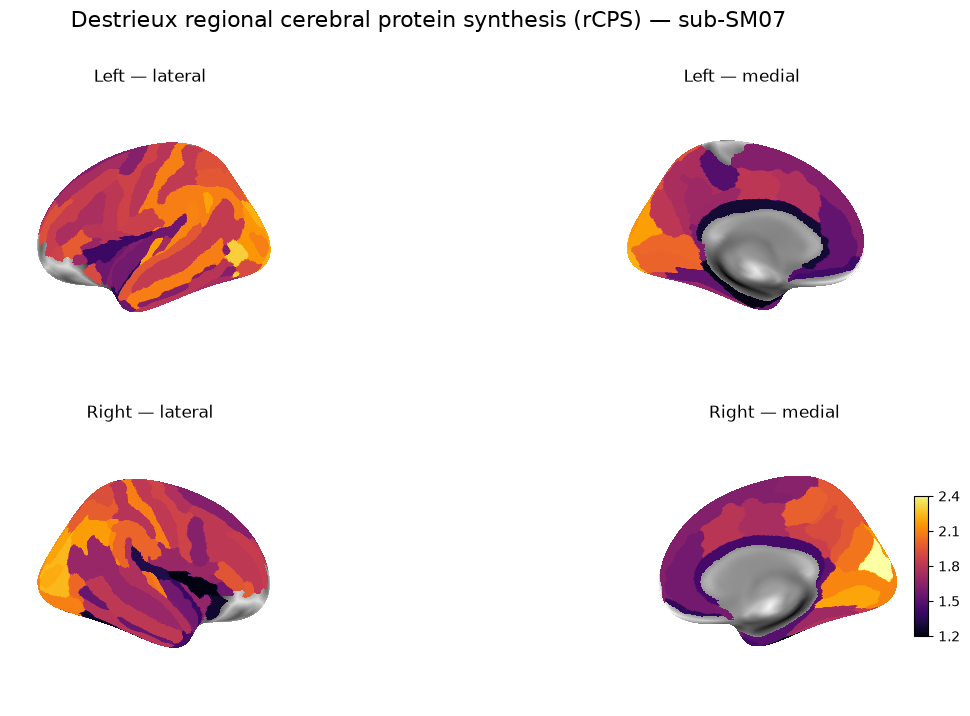

In [34]:
# Use one common scale for both hemispheres
regional_vmin = min(
    np.nanmin(lh_regional_map),
    np.nanmin(rh_regional_map)
)

regional_vmax = max(
    np.nanmax(lh_regional_map),
    np.nanmax(rh_regional_map)
)

fig = plt.figure(figsize=(14, 8))

views = [
    ("left", "lateral", lh_regional_map,
     fsaverage["infl_left"], fsaverage["sulc_left"]),

    ("left", "medial", lh_regional_map,
     fsaverage["infl_left"], fsaverage["sulc_left"]),

    ("right", "lateral", rh_regional_map,
     fsaverage["infl_right"], fsaverage["sulc_right"]),

    ("right", "medial", rh_regional_map,
     fsaverage["infl_right"], fsaverage["sulc_right"])
]

titles = [
    "Left — lateral",
    "Left — medial",
    "Right — lateral",
    "Right — medial"
]

for i, ((hemi, view, data, mesh, sulc), title) in enumerate(
    zip(views, titles)
):

    ax = fig.add_subplot(2, 2, i + 1, projection="3d")

    plotting.plot_surf_stat_map(
        mesh,
        data,
        hemi=hemi,
        view=view,
        bg_map=sulc,
        cmap="inferno",
        vmin=regional_vmin,
        vmax=regional_vmax,
        colorbar=(i == 3),
        axes=ax,
        title=title
    )

fig.suptitle(
    "Destrieux regional cerebral protein synthesis (rCPS) — sub-SM07",
    fontsize=16
)

fig.savefig(
    figures_dir / "SM07_destrieux_regional_rcps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Cohort extraction and coverage QC

The validated extraction workflow is applied to all available participants. Regional measurements with <80% positive finite-vertex coverage are excluded from inferential analyses.


In [35]:
surface_files = []

for participant_dir in participant_dirs:

    participant = participant_dir.name

    lh_files = list(
        participant_dir.glob(
            "*_space-fsaverage_pvc-nopvc_hemi-lh_desc-ArtIF_rcps.nii.gz"
        )
    )

    rh_files = list(
        participant_dir.glob(
            "*_space-fsaverage_pvc-nopvc_hemi-rh_desc-ArtIF_rcps.nii.gz"
        )
    )

    surface_files.append({
        "participant": participant,
        "lh_files": len(lh_files),
        "rh_files": len(rh_files),
        "lh_path": lh_files[0] if len(lh_files) == 1 else None,
        "rh_path": rh_files[0] if len(rh_files) == 1 else None
    })

surface_check = pd.DataFrame(surface_files)

print("Participants checked:", len(surface_check))

print("\nLH file counts:")
print(surface_check["lh_files"].value_counts().sort_index())

print("\nRH file counts:")
print(surface_check["rh_files"].value_counts().sort_index())

Participants checked: 35

LH file counts:
lh_files
1    35
Name: count, dtype: int64

RH file counts:
rh_files
1    35
Name: count, dtype: int64


In [36]:
def get_condition_from_path(path):
    name = Path(path).name

    if "_ses-Asleep_" in name:
        return "Asleep"
    elif "_ses-Awake_" in name:
        return "Awake"
    else:
        return "Unknown"


surface_check["condition"] = surface_check["lh_path"].apply(
    get_condition_from_path
)

print("Condition counts:")
print(surface_check["condition"].value_counts())

surface_check[
    ["participant", "condition", "lh_files", "rh_files"]
].head(10)

Condition counts:
condition
Asleep    18
Awake     17
Name: count, dtype: int64


,participant,condition,lh_files,rh_files
0,sub-SM07,Awake,1,1
1,sub-SM08,Awake,1,1
2,sub-SM09,Asleep,1,1
3,sub-SM10,Awake,1,1
4,sub-SM11,Asleep,1,1
5,sub-SM12,Asleep,1,1
6,sub-SM16,Awake,1,1
7,sub-SM19,Awake,1,1
8,sub-SM21,Asleep,1,1
9,sub-SM22,Awake,1,1


In [37]:
cohort_regions_list = []

for _, row in surface_check.iterrows():

    participant = row["participant"]
    condition = row["condition"]

    print(f"Processing {participant} ({condition})...")

    # Load left and right surface rCPS
    lh_img = nib.load(row["lh_path"])
    rh_img = nib.load(row["rh_path"])

    lh_data = np.asarray(lh_img.dataobj).squeeze()
    rh_data = np.asarray(rh_img.dataobj).squeeze()

    # Extract left hemisphere regions
    lh_regions = extract_regional_rcps(
        lh_data,
        fsavg_lh_labels,
        fsavg_lh_names,
        "left"
    )

    # Extract right hemisphere regions
    rh_regions = extract_regional_rcps(
        rh_data,
        fsavg_rh_labels,
        fsavg_rh_names,
        "right"
    )

    # Combine hemispheres
    participant_regions = pd.concat(
        [lh_regions, rh_regions],
        ignore_index=True
    )

    # Add participant metadata
    participant_regions["participant"] = participant
    participant_regions["condition"] = condition

    cohort_regions_list.append(participant_regions)


# Combine all 35 participants
cohort_regions = pd.concat(
    cohort_regions_list,
    ignore_index=True
)

print("\nCohort extraction complete.")
print("---------------------------")
print("Participants:", cohort_regions["participant"].nunique())
print("Total regional measurements:", len(cohort_regions))

print("\nMeasurements per participant:")
print(
    cohort_regions
    .groupby("participant")
    .size()
    .describe()
)

print("\nCondition counts:")
print(
    cohort_regions[
        ["participant", "condition"]
    ]
    .drop_duplicates()["condition"]
    .value_counts()
)

Processing sub-SM07 (Awake)...
Processing sub-SM08 (Awake)...
Processing sub-SM09 (Asleep)...
Processing sub-SM10 (Awake)...
Processing sub-SM11 (Asleep)...
Processing sub-SM12 (Asleep)...
Processing sub-SM16 (Awake)...
Processing sub-SM19 (Awake)...
Processing sub-SM21 (Asleep)...
Processing sub-SM22 (Awake)...
Processing sub-SM23 (Asleep)...
Processing sub-SM24 (Asleep)...
Processing sub-SM27 (Awake)...
Processing sub-SM28 (Awake)...
Processing sub-SM30 (Asleep)...
Processing sub-SM31 (Awake)...
Processing sub-SM32 (Asleep)...
Processing sub-SM33 (Asleep)...
Processing sub-SM35 (Awake)...
Processing sub-SM36 (Awake)...
Processing sub-SM37 (Asleep)...
Processing sub-SM38 (Awake)...
Processing sub-SM40 (Asleep)...
Processing sub-SM43 (Asleep)...
Processing sub-SM45 (Awake)...
Processing sub-SM47 (Asleep)...
Processing sub-SM48 (Asleep)...
Processing sub-SM50 (Awake)...
Processing sub-SM51 (Awake)...
Processing sub-SM52 (Asleep)...
Processing sub-SM54 (Asleep)...
Processing sub-SM56 (Aw

In [38]:
COVERAGE_THRESHOLD = 0.80

cohort_regions["passes_coverage"] = (
    cohort_regions["coverage"] >= COVERAGE_THRESHOLD
)

print("Total measurements:", len(cohort_regions))
print(
    "Passing ≥80% coverage:",
    cohort_regions["passes_coverage"].sum()
)
print(
    "Below 80% coverage:",
    (~cohort_regions["passes_coverage"]).sum()
)

print(
    "\nPercentage passing:",
    round(cohort_regions["passes_coverage"].mean() * 100, 1),
    "%"
)

Total measurements: 5180
Passing ≥80% coverage: 5062
Below 80% coverage: 118

Percentage passing: 97.7 %


In [39]:
print("cohort_regions shape:", cohort_regions.shape)
print("columns:", cohort_regions.columns.tolist())
print("\nParticipants:", cohort_regions["participant"].nunique() if "participant" in cohort_regions else "NO participant column")
print("Conditions:", cohort_regions["condition"].unique() if "condition" in cohort_regions else "NO condition column")

cohort_regions shape: (5180, 9)
columns: ['hemisphere', 'region', 'n_vertices', 'n_valid', 'coverage', 'mean_rcps', 'participant', 'condition', 'passes_coverage']

Participants: 35
Conditions: <StringArray>
['Awake', 'Asleep']
Length: 2, dtype: str


In [40]:
coverage_by_condition = (
    cohort_regions
    .groupby("condition")["passes_coverage"]
    .agg(["sum", "count", "mean"])
)

coverage_by_condition["percent_passing"] = (
    coverage_by_condition["mean"] * 100
)

coverage_by_condition

,sum,count,mean,percent_passing
condition,,,,
Asleep,2597,2664,0.97485,97.484985
Awake,2465,2516,0.97973,97.972973


In [41]:
low_coverage_by_region = (
    cohort_regions
    .groupby(["hemisphere", "region"])
    .agg(
        n_measurements=("coverage", "size"),
        mean_coverage=("coverage", "mean"),
        min_coverage=("coverage", "min"),
        n_below_80=("passes_coverage", lambda x: (~x).sum())
    )
    .reset_index()
    .sort_values(
        ["n_below_80", "mean_coverage"],
        ascending=[False, True]
    )
)

low_coverage_by_region.head(15)

,hemisphere,region,n_measurements,mean_coverage,min_coverage,n_below_80
104,right,G_rectus,35,0.797118,0.476395,15
30,left,G_rectus,35,0.828667,0.597327,12
23,left,G_orbital,35,0.824036,0.300397,11
97,right,G_orbital,35,0.811170,0.258510,10
105,right,G_subcallosal,35,0.834014,0.203463,9
94,right,G_oc-temp_med-Parahip,35,0.887094,0.716011,3
116,right,Pole_temporal,35,0.905611,0.709571,3
6,left,G_and_S_paracentral,35,0.916147,0.644366,3
63,left,S_orbital_med-olfact,35,0.920542,0.773723,3
137,right,S_orbital_med-olfact,35,0.923239,0.682440,3


In [42]:
cohort_regions.to_csv(
    results_dir / "cohort_regional_rcps.csv",
    index=False
)

print("Saved:")
print(results_dir / "cohort_regional_rcps.csv")

Saved:
C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub\results\cohort_regional_rcps.csv


In [43]:
# Apply the same regional coverage criterion across the full cohort
cohort_regions["passes_coverage"] = (
    cohort_regions["coverage"] >= COVERAGE_THRESHOLD
)

print("Coverage threshold:", f"{COVERAGE_THRESHOLD:.0%}")
print("Measurements passing:", cohort_regions["passes_coverage"].sum(), "of", len(cohort_regions))
print("Participants:", cohort_regions["participant"].nunique())

Coverage threshold: 80%
Measurements passing: 5062 of 5180
Participants: 35


In [44]:
analysis_regions = (
    cohort_regions[
        cohort_regions["passes_coverage"]
    ]
    .copy()
)

print("Analysis-ready measurements:", len(analysis_regions))
print("Participants:", analysis_regions["participant"].nunique())

print("\nBy condition:")
print(
    analysis_regions
    .groupby("condition")
    .agg(
        participants=("participant", "nunique"),
        measurements=("mean_rcps", "size"),
        mean_rcps=("mean_rcps", "mean"),
        sd_rcps=("mean_rcps", "std")
    )
)

Analysis-ready measurements: 5062
Participants: 35

By condition:
           participants  measurements  mean_rcps   sd_rcps
condition                                                 
Asleep               18          2597   1.933997  0.345185
Awake                17          2465   1.909844  0.297446


## 6. Participant-level sleep/wake comparison

Regional values passing QC are aggregated to participant-level cortical means so that the participant—not the cortical parcel—is the unit of inference for the global sleep/wake comparison.


In [45]:
participant_summary = (
    analysis_regions
    .groupby(["participant", "condition"], as_index=False)
    .agg(
        mean_cortical_rcps=("mean_rcps", "mean"),
        n_regions=("mean_rcps", "size"),
        mean_coverage=("coverage", "mean")
    )
)

print(participant_summary)

print("\nParticipant-level summary by condition:")
print(
    participant_summary
    .groupby("condition")["mean_cortical_rcps"]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

   participant condition  mean_cortical_rcps  n_regions  mean_coverage
0     sub-SM07     Awake            1.798013        133       0.937170
1     sub-SM08     Awake            1.846217        145       0.930416
2     sub-SM09    Asleep            1.902010        144       0.962586
3     sub-SM10     Awake            1.743038        147       0.967283
4     sub-SM11    Asleep            1.630671        145       0.962933
5     sub-SM12    Asleep            1.904897        135       0.943035
6     sub-SM16     Awake            1.665475        144       0.940179
7     sub-SM19     Awake            1.828640        144       0.960160
8     sub-SM21    Asleep            1.836673        126       0.927004
9     sub-SM22     Awake            2.096161        141       0.957891
10    sub-SM23    Asleep            1.739164        142       0.929855
11    sub-SM24    Asleep            1.707108        147       0.950321
12    sub-SM27     Awake            1.826093        143       0.947378
13    

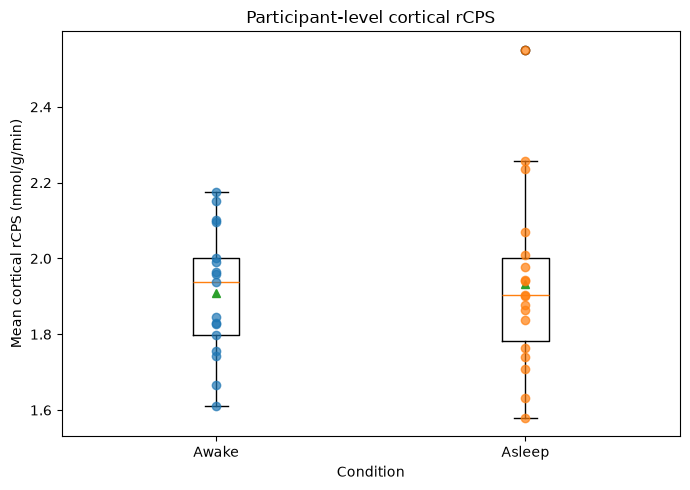

In [46]:
plt.figure(figsize=(7, 5))

conditions = ["Awake", "Asleep"]

data = [
    participant_summary.loc[
        participant_summary["condition"] == condition,
        "mean_cortical_rcps"
    ]
    for condition in conditions
]

plt.boxplot(
    data,
    tick_labels=conditions,
    showmeans=True
)

# Add individual participants
for i, values in enumerate(data, start=1):
    x = np.full(len(values), i)
    plt.scatter(
        x,
        values,
        alpha=0.7,
        zorder=3
    )

plt.ylabel("Mean cortical rCPS (nmol/g/min)")
plt.xlabel("Condition")
plt.title("Participant-level cortical rCPS")

plt.tight_layout()
plt.show()

In [47]:
condition_per_participant = (
    cohort_regions[
        ["participant", "condition"]
    ]
    .drop_duplicates()
    .groupby("participant")["condition"]
    .agg(list)
)

condition_per_participant[
    condition_per_participant.apply(len) > 1
]

Series([], Name: condition, dtype: object)

In [48]:
from scipy import stats

awake = participant_summary.loc[
    participant_summary["condition"] == "Awake",
    "mean_cortical_rcps"
]

asleep = participant_summary.loc[
    participant_summary["condition"] == "Asleep",
    "mean_cortical_rcps"
]

t_stat, p_value = stats.ttest_ind(
    asleep,
    awake,
    equal_var=False
)

print("Welch's independent-samples t-test")
print("-----------------------------------")
print(f"Asleep: M = {asleep.mean():.3f}, SD = {asleep.std(ddof=1):.3f}, n = {len(asleep)}")
print(f"Awake:  M = {awake.mean():.3f}, SD = {awake.std(ddof=1):.3f}, n = {len(awake)}")
print(f"Mean difference (Asleep - Awake) = {asleep.mean() - awake.mean():.3f}")
print(f"t = {t_stat:.3f}")
print(f"p = {p_value:.4f}")

Welch's independent-samples t-test
-----------------------------------
Asleep: M = 1.933, SD = 0.237, n = 18
Awake:  M = 1.909, SD = 0.168, n = 17
Mean difference (Asleep - Awake) = 0.024
t = 0.341
p = 0.7353


In [49]:
# Mean difference
mean_diff = asleep.mean() - awake.mean()

# Standard error for Welch comparison
se_diff = np.sqrt(
    asleep.var(ddof=1) / len(asleep) +
    awake.var(ddof=1) / len(awake)
)

# Welch-Satterthwaite degrees of freedom
df = (
    (asleep.var(ddof=1) / len(asleep) +
     awake.var(ddof=1) / len(awake)) ** 2
    /
    (
        (asleep.var(ddof=1) / len(asleep)) ** 2 / (len(asleep) - 1)
        +
        (awake.var(ddof=1) / len(awake)) ** 2 / (len(awake) - 1)
    )
)

t_crit = stats.t.ppf(0.975, df)

ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

# Cohen's d using pooled SD
pooled_sd = np.sqrt(
    (
        (len(asleep) - 1) * asleep.var(ddof=1)
        + (len(awake) - 1) * awake.var(ddof=1)
    )
    / (len(asleep) + len(awake) - 2)
)

cohens_d = mean_diff / pooled_sd

print(f"Welch df = {df:.2f}")
print(f"95% CI for mean difference = [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Cohen's d = {cohens_d:.3f}")

Welch df = 30.67
95% CI for mean difference = [-0.118, 0.165]
Cohen's d = 0.114


## 7. Regional sleep/wake differences

Hemisphere-specific Destrieux parcels are compared descriptively and inferentially. Multiple comparisons are controlled using Benjamini–Hochberg FDR correction.


In [50]:
condition_regions = (
    analysis_regions
    .groupby(
        ["condition", "hemisphere", "region"],
        as_index=False
    )
    .agg(
        mean_rcps=("mean_rcps", "mean"),
        sd_rcps=("mean_rcps", "std"),
        n=("mean_rcps", "count"),
        mean_coverage=("coverage", "mean")
    )
)

print("Rows:", len(condition_regions))

print("\nRows by condition:")
print(condition_regions["condition"].value_counts())

condition_regions.head()

Rows: 296

Rows by condition:
condition
Asleep    148
Awake     148
Name: count, dtype: int64


,condition,hemisphere,region,mean_rcps,sd_rcps,n,mean_coverage
0,Asleep,left,G_Ins_lg_and_S_cent_ins,1.789937,0.298118,18,0.937581
1,Asleep,left,G_and_S_cingul-Ant,1.755514,0.179891,18,0.953350
2,Asleep,left,G_and_S_cingul-Mid-Ant,1.911435,0.328990,18,0.954210
3,Asleep,left,G_and_S_cingul-Mid-Post,1.787781,0.228796,18,0.941324
4,Asleep,left,G_and_S_frontomargin,2.115550,0.285083,18,0.955711


In [51]:
regional_comparison = (
    condition_regions
    .pivot(
        index=["hemisphere", "region"],
        columns="condition",
        values="mean_rcps"
    )
    .reset_index()
)

regional_comparison["difference"] = (
    regional_comparison["Asleep"]
    - regional_comparison["Awake"]
)

regional_comparison["percent_difference"] = (
    regional_comparison["difference"]
    / regional_comparison["Awake"]
) * 100

print("Regions:", len(regional_comparison))

regional_comparison.head(10)

Regions: 148


condition,hemisphere,region,Asleep,Awake,difference,percent_difference
0,left,G_Ins_lg_and_S_cent_ins,1.789937,1.760331,0.029606,1.681815
1,left,G_and_S_cingul-Ant,1.755514,1.773816,-0.018302,-1.031765
2,left,G_and_S_cingul-Mid-Ant,1.911435,1.819087,0.092348,5.076626
3,left,G_and_S_cingul-Mid-Post,1.787781,1.872687,-0.084906,-4.533905
4,left,G_and_S_frontomargin,2.115550,1.994533,0.121017,6.067435
5,left,G_and_S_occipital_inf,2.145493,2.154471,-0.008978,-0.416721
6,left,G_and_S_paracentral,1.801343,1.789832,0.011511,0.643144
7,left,G_and_S_subcentral,2.121410,2.106190,0.015219,0.722594
8,left,G_and_S_transv_frontopol,2.006629,2.017421,-0.010791,-0.534906
9,left,G_cingul-Post-dorsal,1.959214,1.948289,0.010925,0.560757


In [52]:
from IPython.display import display
print("Largest Asleep > Awake differences")
display(
    regional_comparison
    .sort_values("difference", ascending=False)
    .head(10)
)

print("\nLargest Awake > Asleep differences")
display(
    regional_comparison
    .sort_values("difference")
    .head(10)
)

Largest Asleep > Awake differences


condition,hemisphere,region,Asleep,Awake,difference,percent_difference
73,left,S_temporal_transverse,2.177692,1.988168,0.189525,9.532622
104,right,G_rectus,2.025153,1.856755,0.168398,9.069452
143,right,S_suborbital,1.883222,1.739350,0.143872,8.271626
68,left,S_precentral-sup-part,1.871056,1.733701,0.137355,7.922657
67,left,S_precentral-inf-part,1.959870,1.830891,0.128979,7.044600
4,left,G_and_S_frontomargin,2.115550,1.994533,0.121017,6.067435
87,right,G_front_inf-Orbital,2.030069,1.912523,0.117546,6.146121
128,right,S_interm_prim-Jensen,2.075999,1.977992,0.098007,4.954890
25,left,G_pariet_inf-Supramar,2.185958,2.089104,0.096854,4.636160
105,right,G_subcallosal,1.729491,1.634501,0.094990,5.811539



Largest Awake > Asleep differences


condition,hemisphere,region,Asleep,Awake,difference,percent_difference
134,right,S_occipital_ant,1.966339,2.090302,-0.123963,-5.930404
31,left,G_subcallosal,1.518000,1.641489,-0.123488,-7.522946
38,left,Lat_Fis-ant-Horizont,1.671075,1.779793,-0.108718,-6.108466
109,right,G_temp_sup-Plan_tempo,2.011477,2.118570,-0.107093,-5.054959
106,right,G_temp_sup-G_T_transv,2.191229,2.289896,-0.098666,-4.308774
3,left,G_and_S_cingul-Mid-Post,1.787781,1.872687,-0.084906,-4.533905
41,left,Pole_occipital,2.420849,2.503919,-0.083070,-3.317582
135,right,S_orbital-H_Shaped,1.708719,1.787563,-0.078844,-4.410695
131,right,S_oc-temp_med_and_Lingual,1.785817,1.856212,-0.070396,-3.792432
132,right,S_oc_middle_and_Lunatus,2.061154,2.126570,-0.065416,-3.076132


In [53]:
# Empty surface arrays
lh_awake = np.full(len(fsavg_lh_labels), np.nan)
lh_asleep = np.full(len(fsavg_lh_labels), np.nan)

rh_awake = np.full(len(fsavg_rh_labels), np.nan)
rh_asleep = np.full(len(fsavg_rh_labels), np.nan)


# LEFT hemisphere
for label_id, region_name in enumerate(fsavg_lh_names):

    if region_name.lower() == "unknown":
        continue

    row = regional_comparison[
        (regional_comparison["hemisphere"] == "left") &
        (regional_comparison["region"] == region_name)
    ]

    if len(row) == 1:
        mask = fsavg_lh_labels == label_id

        lh_awake[mask] = row["Awake"].iloc[0]
        lh_asleep[mask] = row["Asleep"].iloc[0]


# RIGHT hemisphere
for label_id, region_name in enumerate(fsavg_rh_names):

    if region_name.lower() == "unknown":
        continue

    row = regional_comparison[
        (regional_comparison["hemisphere"] == "right") &
        (regional_comparison["region"] == region_name)
    ]

    if len(row) == 1:
        mask = fsavg_rh_labels == label_id

        rh_awake[mask] = row["Awake"].iloc[0]
        rh_asleep[mask] = row["Asleep"].iloc[0]


# Difference maps
lh_difference = lh_asleep - lh_awake
rh_difference = rh_asleep - rh_awake


print("Surface maps created.")
print("---------------------")
print("LH Awake mapped:", np.isfinite(lh_awake).sum())
print("LH Asleep mapped:", np.isfinite(lh_asleep).sum())
print("RH Awake mapped:", np.isfinite(rh_awake).sum())
print("RH Asleep mapped:", np.isfinite(rh_asleep).sum())

print("\nDifference range:")
print(
    round(np.nanmin(np.concatenate([lh_difference, rh_difference])), 3),
    "to",
    round(np.nanmax(np.concatenate([lh_difference, rh_difference])), 3),
    "nmol/g/min"
)

Surface maps created.
---------------------
LH Awake mapped: 149955
LH Asleep mapped: 149955
RH Awake mapped: 149926
RH Asleep mapped: 149926

Difference range:
-0.124 to 0.19 nmol/g/min


Shared display range: 1.502 to 2.36 nmol/g/min


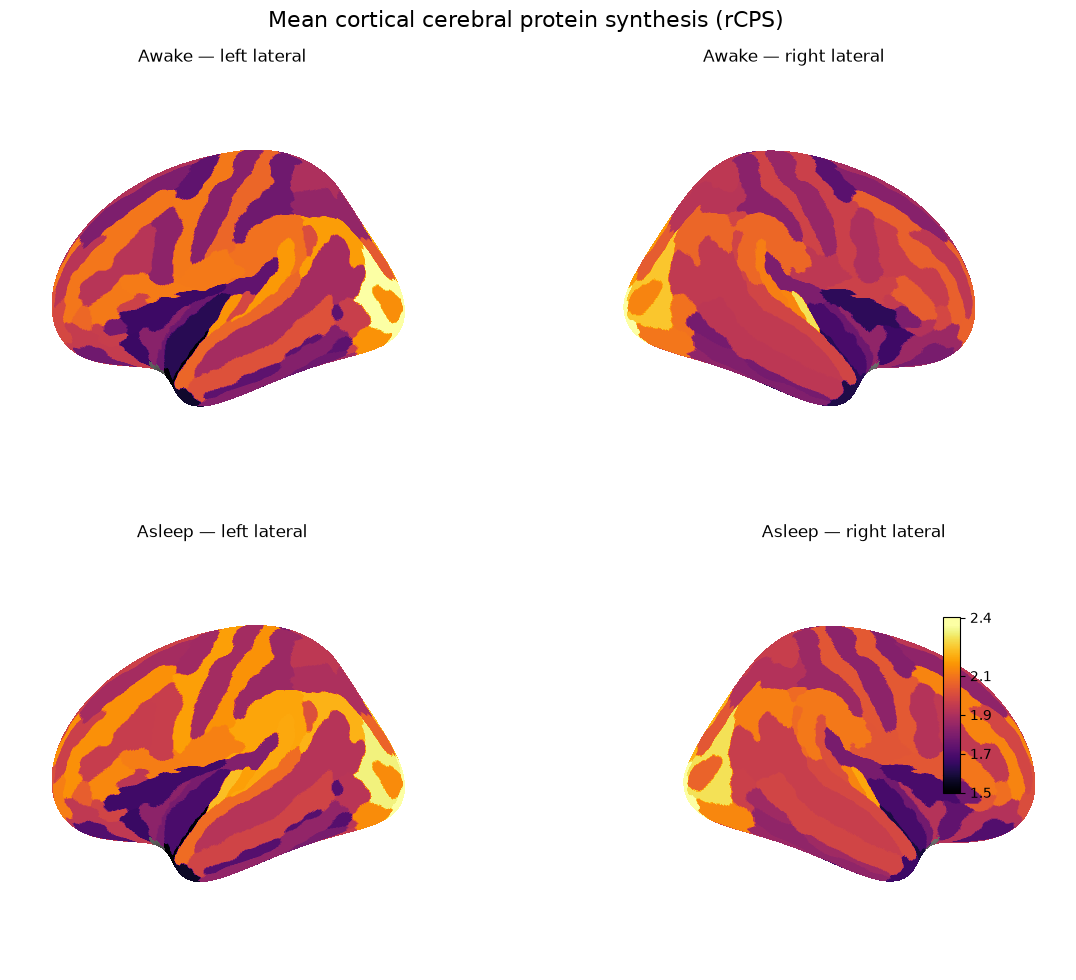

In [54]:
from nilearn import plotting
import matplotlib.pyplot as plt
import numpy as np

# Shared colour range across BOTH conditions
absolute_values = np.concatenate([
    lh_awake[np.isfinite(lh_awake)],
    rh_awake[np.isfinite(rh_awake)],
    lh_asleep[np.isfinite(lh_asleep)],
    rh_asleep[np.isfinite(rh_asleep)]
])

abs_vmin = np.percentile(absolute_values, 2)
abs_vmax = np.percentile(absolute_values, 98)

print(
    "Shared display range:",
    round(abs_vmin, 3),
    "to",
    round(abs_vmax, 3),
    "nmol/g/min"
)

fig = plt.figure(figsize=(12, 10))

plots = [
    (lh_awake,  "left",  "lateral", "Awake — left lateral"),
    (rh_awake,  "right", "lateral", "Awake — right lateral"),
    (lh_asleep, "left",  "lateral", "Asleep — left lateral"),
    (rh_asleep, "right", "lateral", "Asleep — right lateral"),
]

for i, (data, hemi, view, title) in enumerate(plots, start=1):

    ax = fig.add_subplot(2, 2, i, projection="3d")

    plotting.plot_surf_stat_map(
        fsaverage[f"infl_{hemi}"],
        data,
        hemi=hemi,
        view=view,
        bg_map=fsaverage[f"sulc_{hemi}"],
        cmap="inferno",
        vmin=abs_vmin,
        vmax=abs_vmax,
        colorbar=(i == 4),
        axes=ax,
        title=title
    )

fig.suptitle(
    "Mean cortical cerebral protein synthesis (rCPS)",
    fontsize=16
)

plt.subplots_adjust(
    left=0.02,
    right=0.95,
    bottom=0.02,
    top=0.92,
    wspace=0.05,
    hspace=0.12
)

plt.savefig(
    figures_dir / "awake_vs_asleep_cortical_rcps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Difference display range: -0.19 to 0.19 nmol/g/min


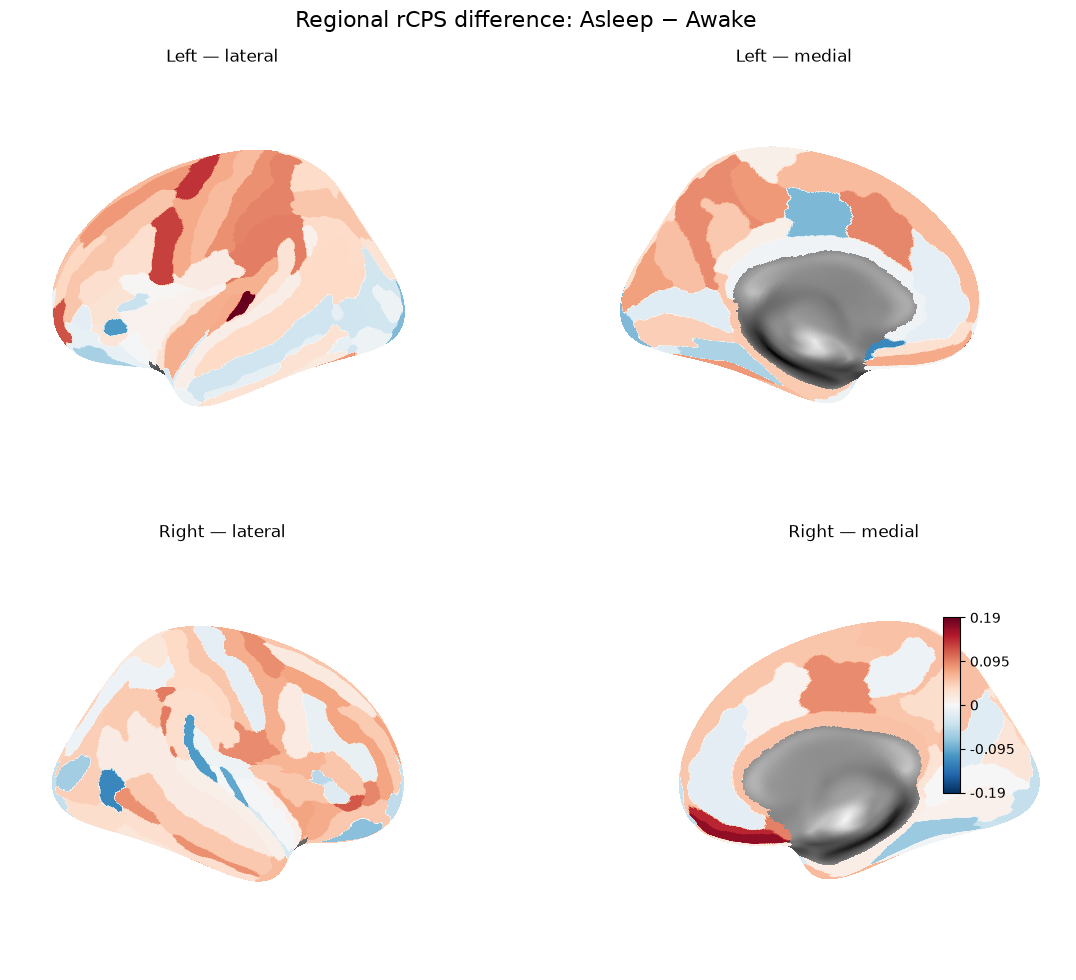

In [55]:
difference_values = np.concatenate([
    lh_difference[np.isfinite(lh_difference)],
    rh_difference[np.isfinite(rh_difference)]
])

# Symmetrical limit around zero
diff_limit = np.max(np.abs(difference_values))

print(
    "Difference display range:",
    round(-diff_limit, 3),
    "to",
    round(diff_limit, 3),
    "nmol/g/min"
)

fig = plt.figure(figsize=(12, 10))

plots = [
    (lh_difference, "left",  "lateral", "Left — lateral"),
    (lh_difference, "left",  "medial",  "Left — medial"),
    (rh_difference, "right", "lateral", "Right — lateral"),
    (rh_difference, "right", "medial",  "Right — medial"),
]

for i, (data, hemi, view, title) in enumerate(plots, start=1):

    ax = fig.add_subplot(2, 2, i, projection="3d")

    plotting.plot_surf_stat_map(
        fsaverage[f"infl_{hemi}"],
        data,
        hemi=hemi,
        view=view,
        bg_map=fsaverage[f"sulc_{hemi}"],
        cmap="RdBu_r",
        vmin=-diff_limit,
        vmax=diff_limit,
        colorbar=(i == 4),
        axes=ax,
        title=title
    )

fig.suptitle(
    "Regional rCPS difference: Asleep − Awake",
    fontsize=16
)

plt.subplots_adjust(
    left=0.02,
    right=0.95,
    bottom=0.02,
    top=0.92,
    wspace=0.05,
    hspace=0.12
)

plt.savefig(
    figures_dir / "asleep_minus_awake_rcps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

regional_tests = []

for (hemisphere, region), group in analysis_regions.groupby(
    ["hemisphere", "region"]
):

    asleep = group.loc[
        group["condition"] == "Asleep", "mean_rcps"
    ].dropna()

    awake = group.loc[
        group["condition"] == "Awake", "mean_rcps"
    ].dropna()

    # Welch independent-samples t-test
    t_stat, p_value = ttest_ind(
        asleep,
        awake,
        equal_var=False
    )

    mean_asleep = asleep.mean()
    mean_awake = awake.mean()
    difference = mean_asleep - mean_awake

    regional_tests.append({
        "hemisphere": hemisphere,
        "region": region,
        "n_asleep": len(asleep),
        "n_awake": len(awake),
        "mean_asleep": mean_asleep,
        "mean_awake": mean_awake,
        "difference": difference,
        "t": t_stat,
        "p_uncorrected": p_value
    })

regional_tests = pd.DataFrame(regional_tests)

print("Regional tests:", len(regional_tests))
regional_tests.head()

Regional tests: 148


,hemisphere,region,n_asleep,n_awake,mean_asleep,mean_awake,difference,t,p_uncorrected
0,left,G_Ins_lg_and_S_cent_ins,18,17,1.789937,1.760331,0.029606,0.297793,0.767729
1,left,G_and_S_cingul-Ant,18,17,1.755515,1.773816,-0.018301,-0.297423,0.768020
2,left,G_and_S_cingul-Mid-Ant,18,17,1.911435,1.819086,0.092349,1.020595,0.316286
3,left,G_and_S_cingul-Mid-Post,18,17,1.787781,1.872687,-0.084906,-1.053868,0.299736
4,left,G_and_S_frontomargin,18,16,2.115549,1.994533,0.121017,1.444623,0.158772


In [57]:
reject, p_fdr, _, _ = multipletests(
    regional_tests["p_uncorrected"],
    alpha=0.05,
    method="fdr_bh"
)

regional_tests["p_fdr"] = p_fdr
regional_tests["significant_fdr"] = reject

print(
    "FDR-significant regions:",
    regional_tests["significant_fdr"].sum()
)

print(
    "Smallest uncorrected p:",
    regional_tests["p_uncorrected"].min()
)

print(
    "Smallest FDR-adjusted p:",
    regional_tests["p_fdr"].min()
)

FDR-significant regions: 0
Smallest uncorrected p: 0.117043726
Smallest FDR-adjusted p: 0.9706263978716354


In [58]:
regional_tests_sorted = regional_tests.sort_values(
    "p_uncorrected"
)

regional_tests_sorted[
    [
        "hemisphere",
        "region",
        "n_asleep",
        "n_awake",
        "mean_asleep",
        "mean_awake",
        "difference",
        "t",
        "p_uncorrected",
        "p_fdr",
        "significant_fdr"
    ]
].head(15)

,hemisphere,region,n_asleep,n_awake,mean_asleep,mean_awake,difference,t,p_uncorrected,p_fdr,significant_fdr
143,right,S_suborbital,17,17,1.883222,1.739350,0.143872,1.613792,0.117044,0.970626,False
68,left,S_precentral-sup-part,18,17,1.871056,1.733701,0.137355,1.594013,0.121412,0.970626,False
73,left,S_temporal_transverse,18,17,2.177692,1.988168,0.189525,1.446941,0.157354,0.970626,False
4,left,G_and_S_frontomargin,18,16,2.115549,1.994533,0.121017,1.444623,0.158772,0.970626,False
67,left,S_precentral-inf-part,18,17,1.959870,1.830891,0.128979,1.281011,0.211169,0.970626,False
104,right,G_rectus,8,12,2.025153,1.856755,0.168398,1.298391,0.220788,0.970626,False
142,right,S_precentral-sup-part,18,17,1.813550,1.726105,0.087445,1.203650,0.238320,0.970626,False
145,right,S_temporal_inf,18,17,1.867924,1.781003,0.086922,1.193946,0.241087,0.970626,False
31,left,G_subcallosal,17,16,1.518000,1.641489,-0.123488,-1.191220,0.242820,0.970626,False
109,right,G_temp_sup-Plan_tempo,18,17,2.011477,2.118570,-0.107093,-1.175055,0.248726,0.970626,False


In [59]:
print("Direction of descriptive differences:")
print(
    "Asleep > Awake:",
    (regional_tests["difference"] > 0).sum()
)

print(
    "Awake > Asleep:",
    (regional_tests["difference"] < 0).sum()
)

Direction of descriptive differences:
Asleep > Awake: 101
Awake > Asleep: 47


In [60]:
# Save complete regional statistics
regional_tests.to_csv(
    results_dir / "regional_awake_asleep_statistics.csv",
    index=False
)

# Save participant-level cortical estimates
participant_summary.to_csv(
    results_dir / "participant_cortical_rcps.csv",
    index=False
)

# Save analysis-ready regional data
analysis_regions.to_csv(
    results_dir / "regional_rcps_analysis_ready.csv",
    index=False
)

# Compact table of strongest descriptive regional differences
top_regional_results = (
    regional_tests
    .sort_values("p_uncorrected")
    .head(15)
    .copy()
)

top_regional_results.to_csv(
    results_dir / "top_regional_comparisons.csv",
    index=False
)

print("Results saved.")
print("-------------------------------")
print("Participants: 35")
print("Asleep: 18")
print("Awake: 17")
print("Regional measurements analysed:", len(analysis_regions))
print("Regional tests:", len(regional_tests))
print("FDR-significant regions:",
      regional_tests["significant_fdr"].sum())

Results saved.
-------------------------------
Participants: 35
Asleep: 18
Awake: 17
Regional measurements analysed: 5062
Regional tests: 148
FDR-significant regions: 0


In [61]:
# Strongest descriptive Asleep > Awake differences
print("Largest Asleep > Awake regional differences")
display(
    regional_tests
    .sort_values("difference", ascending=False)
    [[
        "hemisphere",
        "region",
        "mean_asleep",
        "mean_awake",
        "difference",
        "t",
        "p_uncorrected",
        "p_fdr"
    ]]
    .head(10)
)

# Strongest descriptive Awake > Asleep differences
print("\nLargest Awake > Asleep regional differences")
display(
    regional_tests
    .sort_values("difference", ascending=True)
    [[
        "hemisphere",
        "region",
        "mean_asleep",
        "mean_awake",
        "difference",
        "t",
        "p_uncorrected",
        "p_fdr"
    ]]
    .head(10)
)

Largest Asleep > Awake regional differences


,hemisphere,region,mean_asleep,mean_awake,difference,t,p_uncorrected,p_fdr
73,left,S_temporal_transverse,2.177692,1.988168,0.189525,1.446941,0.157354,0.970626
104,right,G_rectus,2.025153,1.856755,0.168398,1.298391,0.220788,0.970626
143,right,S_suborbital,1.883222,1.739350,0.143872,1.613792,0.117044,0.970626
68,left,S_precentral-sup-part,1.871056,1.733701,0.137355,1.594013,0.121412,0.970626
67,left,S_precentral-inf-part,1.959870,1.830891,0.128979,1.281011,0.211169,0.970626
4,left,G_and_S_frontomargin,2.115549,1.994533,0.121017,1.444623,0.158772,0.970626
87,right,G_front_inf-Orbital,2.030069,1.912523,0.117546,0.954925,0.348189,0.970626
128,right,S_interm_prim-Jensen,2.075999,1.977992,0.098007,0.990512,0.330216,0.970626
25,left,G_pariet_inf-Supramar,2.185958,2.089104,0.096854,1.050225,0.302059,0.970626
105,right,G_subcallosal,1.729491,1.634501,0.094990,0.589068,0.561331,0.970626



Largest Awake > Asleep regional differences


,hemisphere,region,mean_asleep,mean_awake,difference,t,p_uncorrected,p_fdr
134,right,S_occipital_ant,1.966339,2.090302,-0.123963,-1.116865,0.272359,0.970626
31,left,G_subcallosal,1.518000,1.641489,-0.123488,-1.191220,0.242820,0.970626
38,left,Lat_Fis-ant-Horizont,1.671075,1.779793,-0.108718,-0.998772,0.325709,0.970626
109,right,G_temp_sup-Plan_tempo,2.011477,2.118570,-0.107093,-1.175055,0.248726,0.970626
106,right,G_temp_sup-G_T_transv,2.191229,2.289896,-0.098667,-1.097625,0.280342,0.970626
3,left,G_and_S_cingul-Mid-Post,1.787781,1.872687,-0.084906,-1.053868,0.299736,0.970626
41,left,Pole_occipital,2.420849,2.503919,-0.083070,-0.843352,0.406014,0.970626
135,right,S_orbital-H_Shaped,1.708719,1.787563,-0.078844,-1.052050,0.301338,0.970626
131,right,S_oc-temp_med_and_Lingual,1.785817,1.856212,-0.070396,-0.869145,0.391063,0.970626
132,right,S_oc_middle_and_Lunatus,2.061154,2.126570,-0.065416,-0.681930,0.500108,0.970626


## 8. Cortex-wide directionality and inference


Participant-level mean cortical rCPS was similar between the asleep and awake groups. Mean cortical rCPS was 1.933 ± 0.237 nmol/g/min in the asleep group (n = 18) and 1.909 ± 0.168 nmol/g/min in the awake group (n = 17). A Welch independent-samples t-test provided no evidence of a group difference (mean difference = 0.024 nmol/g/min, t(30.67) = 0.341, p = 0.735, 95% CI [-0.118, 0.165], Cohen's d = 0.114).

Regional Destrieux-parcellated maps revealed modest spatial variation in the direction and magnitude of descriptive asleep–awake differences. Of 148 hemisphere-specific cortical regions, 101 showed numerically higher mean rCPS in the asleep group and 47 showed numerically higher mean rCPS in the awake group. However, none of the 148 regional Welch tests survived Benjamini–Hochberg false-discovery-rate correction (minimum uncorrected p = 0.117; minimum FDR-adjusted p = 0.971).

Accordingly, the regional difference maps are interpreted descriptively rather than as evidence of statistically significant regional effects.

### Directionality sanity check

A simple sign test can make the 101/148 positive regional differences appear highly unusual, but cortical parcels are **not independent experimental units**. The binomial result is therefore shown only as a descriptive warning. The participant-level permutation test below preserves the participant as the unit of exchangeability and is used for inference about the cortex-wide directional pattern.


In [62]:
from scipy.stats import binomtest

n_positive = (regional_tests["difference"] > 0).sum()
n_negative = (regional_tests["difference"] < 0).sum()

direction_test = binomtest(
    n_positive,
    n_positive + n_negative,
    p=0.5,
    alternative="two-sided"
)

print("Asleep > Awake:", n_positive)
print("Awake > Asleep:", n_negative)
print("Proportion positive:", round(n_positive / 148, 3))
print("Binomial p:", direction_test.pvalue)

Asleep > Awake: 101
Awake > Asleep: 47
Proportion positive: 0.682
Binomial p: 1.0683059075368201e-05


In [63]:
# Participant-level permutation test of directional regional pattern

rng = np.random.default_rng(42)

participants = (
    analysis_regions[
        ["participant", "condition"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

participant_ids = participants["participant"].to_numpy()

n_asleep = (participants["condition"] == "Asleep").sum()
n_permutations = 10000

# Participant × region matrix
regional_matrix = (
    analysis_regions
    .pivot_table(
        index="participant",
        columns=["hemisphere", "region"],
        values="mean_rcps"
    )
    .reindex(participant_ids)
)

# Observed regional differences
observed_asleep = participants.loc[
    participants["condition"] == "Asleep",
    "participant"
]

observed_awake = participants.loc[
    participants["condition"] == "Awake",
    "participant"
]

observed_difference = (
    regional_matrix.loc[observed_asleep].mean(axis=0)
    -
    regional_matrix.loc[observed_awake].mean(axis=0)
)

observed_positive = (observed_difference > 0).sum()

# Permutation distribution
permuted_positive = np.empty(n_permutations, dtype=int)

for i in range(n_permutations):

    shuffled = rng.permutation(participant_ids)

    perm_asleep = shuffled[:n_asleep]
    perm_awake = shuffled[n_asleep:]

    perm_difference = (
        regional_matrix.loc[perm_asleep].mean(axis=0)
        -
        regional_matrix.loc[perm_awake].mean(axis=0)
    )

    permuted_positive[i] = (perm_difference > 0).sum()


# Two-sided test based on deviation from 50%
observed_deviation = abs(observed_positive - regional_matrix.shape[1] / 2)

permuted_deviation = abs(
    permuted_positive - regional_matrix.shape[1] / 2
)

p_permutation = (
    np.sum(permuted_deviation >= observed_deviation) + 1
) / (n_permutations + 1)


print("Observed positive regions:", observed_positive)
print("Total regions:", regional_matrix.shape[1])

print(
    "Observed proportion:",
    round(observed_positive / regional_matrix.shape[1], 3)
)

print(
    "Mean positive regions under permutation:",
    round(permuted_positive.mean(), 1)
)

print(
    "95% permutation range:",
    np.percentile(permuted_positive, [2.5, 97.5])
)

print(
    "Two-sided permutation p:",
    p_permutation
)

Observed positive regions: 101
Total regions: 148
Observed proportion: 0.682
Mean positive regions under permutation: 74.2
95% permutation range: [  2. 147.]
Two-sided permutation p: 0.7654234576542346


## 9. Memory-consolidation hypothesis: trained visual cortex

The source experiment trained one visual field before the sleep/wake interval. Because visual-field input projects predominantly to the contralateral hemisphere, the trained field provides a participant-specific way to define **trained V1** versus **untrained V1**. This makes the V1 comparison the most direct PET analysis in this notebook of an experience-dependent molecular signature relevant to visual memory consolidation.

FreeSurfer V1 ex-vivo surface labels are used to extract mean positive rCPS from left and right V1. For participants trained in the right visual field, left V1 is designated trained; for participants trained in the left visual field, right V1 is designated trained.


In [64]:
# Locate V1 ex-vivo surface labels.
# Place lh.V1_exvivo.thresh.label and rh.V1_exvivo.thresh.label under annotations/.
lh_v1_path = annotations_dir / "lh.V1_exvivo.thresh.label"
rh_v1_path = annotations_dir / "rh.V1_exvivo.thresh.label"

if not lh_v1_path.exists() or not rh_v1_path.exists():
    raise FileNotFoundError(
        "V1 ex-vivo labels are required for the memory-consolidation analysis. "
        "Place lh.V1_exvivo.thresh.label and rh.V1_exvivo.thresh.label in annotations/."
    )

lh_v1_vertices = fsio.read_label(lh_v1_path)
rh_v1_vertices = fsio.read_label(rh_v1_path)

print("Left V1 vertices:", len(lh_v1_vertices))
print("Right V1 vertices:", len(rh_v1_vertices))


Left V1 vertices: 3405
Right V1 vertices: 3232


In [65]:
# Participant metadata required for trained-field mapping.
# Trained visual-field metadata are recovered from the validated
# participant-level results generated in the original analysis.

old_v1_path = Path.home() / "PET_memory_project" / "v1_rcps_results.csv"
old_v1 = pd.read_csv(old_v1_path)

memory_meta = (
    old_v1[
        ["participant", "condition", "trained_visual_field"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

required = {"participant", "condition", "trained_visual_field"}
missing = required - set(memory_meta.columns)

if missing:
    raise ValueError(f"Missing metadata columns: {sorted(missing)}")

print("Participants with metadata:", memory_meta["participant"].nunique())
print("\nTrained visual field:")
print(memory_meta["trained_visual_field"].value_counts())


Participants with metadata: 35

Trained visual field:
trained_visual_field
right    18
left     17
Name: count, dtype: int64


In [66]:
from pathlib import Path
import pandas as pd

old_project = Path.home() / "PET_memory_project"

for f in sorted(old_project.glob("*.csv")):
    try:
        df = pd.read_csv(f)
        print("\n", f.name)
        print("Rows:", len(df))
        print("Columns:", list(df.columns))
    except Exception as e:
        print("Could not read:", f.name, e)


 destrieux_lateralisation_stats.csv
Rows: 74
Columns: ['region', 'n_asleep', 'n_awake', 'mean_asleep', 'mean_awake', 'mean_difference', 't', 'df', 'p', 'ci_low', 'ci_high', 'cohens_d', 'p_fdr', 'fdr_significant']

 destrieux_lateralisation_stats_coverage80.csv
Rows: 74
Columns: ['region', 'n_asleep', 'n_awake', 'mean_asleep', 'mean_awake', 'mean_difference', 't', 'df', 'p', 'ci_low', 'ci_high', 'cohens_d', 'p_fdr', 'fdr_significant']

 destrieux_rcps_all_participants.csv
Rows: 5250
Columns: ['participant', 'session', 'condition', 'trained_visual_field', 'hemisphere', 'region', 'mean_rcps', 'n_atlas_vertices', 'n_valid_vertices', 'coverage']

 destrieux_trained_untrained_rcps.csv
Rows: 2590
Columns: ['participant', 'condition', 'trained_visual_field', 'region', 'mean_rcps_left', 'mean_rcps_right', 'coverage_left', 'coverage_right', 'trained_rcps', 'untrained_rcps', 'trained_coverage', 'untrained_coverage', 'difference', 'min_coverage']

 v1_rcps_results.csv
Rows: 35
Columns: ['particip

In [67]:
from pathlib import Path
import pandas as pd

old_v1_path = Path.home() / "PET_memory_project" / "v1_rcps_results.csv"
old_v1 = pd.read_csv(old_v1_path)

print("Rows:", len(old_v1))
print("\nTrained visual field counts:")
print(old_v1["trained_visual_field"].value_counts(dropna=False))

print("\nFirst 10 participants:")
display(
    old_v1[
        ["participant", "condition", "trained_visual_field"]
    ].head(10)
)

print("\nMissing values:")
print(
    old_v1[
        ["participant", "condition", "trained_visual_field"]
    ].isna().sum()
)

Rows: 35

Trained visual field counts:
trained_visual_field
right    18
left     17
Name: count, dtype: int64

First 10 participants:


,participant,condition,trained_visual_field
0,sub-SM07,Awake,right
1,sub-SM08,Awake,right
2,sub-SM09,Asleep,right
3,sub-SM10,Awake,left
4,sub-SM11,Asleep,right
5,sub-SM12,Asleep,right
6,sub-SM16,Awake,left
7,sub-SM19,Awake,right
8,sub-SM21,Asleep,left
9,sub-SM22,Awake,right



Missing values:
participant             0
condition               0
trained_visual_field    0
dtype: int64


In [68]:
# Build minimal metadata for the primary trained/untrained V1 analysis
memory_meta = (
    old_v1[
        ["participant", "condition", "trained_visual_field"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Check that every PET participant has metadata
pet_participants = set(surface_check["participant"])
meta_participants = set(memory_meta["participant"])

print("Metadata participants:", len(meta_participants))
print("Missing from metadata:", sorted(pet_participants - meta_participants))
print("Extra in metadata:", sorted(meta_participants - pet_participants))

display(memory_meta.head())

Metadata participants: 35
Missing from metadata: []
Extra in metadata: []


,participant,condition,trained_visual_field
0,sub-SM07,Awake,right
1,sub-SM08,Awake,right
2,sub-SM09,Asleep,right
3,sub-SM10,Awake,left
4,sub-SM11,Asleep,right


In [69]:
def extract_v1_mean(rcps, vertices):
    values = rcps[vertices]
    valid = np.isfinite(values) & (values > 0)
    return np.mean(values[valid]) if valid.any() else np.nan

v1_rows = []

for _, row in surface_check.iterrows():
    participant = row["participant"]
    condition = row["condition"]

    meta = memory_meta.loc[memory_meta["participant"] == participant]
    if len(meta) != 1:
        raise ValueError(f"Expected one metadata row for {participant}; found {len(meta)}")

    trained_field = str(meta.iloc[0]["trained_visual_field"]).lower()

    lh_data = np.asarray(nib.load(row["lh_path"]).dataobj).squeeze()
    rh_data = np.asarray(nib.load(row["rh_path"]).dataobj).squeeze()

    left_v1 = extract_v1_mean(lh_data, lh_v1_vertices)
    right_v1 = extract_v1_mean(rh_data, rh_v1_vertices)

    if trained_field == "right":
        trained_v1, untrained_v1 = left_v1, right_v1
    elif trained_field == "left":
        trained_v1, untrained_v1 = right_v1, left_v1
    else:
        raise ValueError(f"Unexpected trained visual field for {participant}: {trained_field}")

    v1_rows.append({
        "participant": participant,
        "condition": condition,
        "trained_visual_field": trained_field,
        "left_v1": left_v1,
        "right_v1": right_v1,
        "trained_v1": trained_v1,
        "untrained_v1": untrained_v1,
        "difference": trained_v1 - untrained_v1
    })

v1 = pd.DataFrame(v1_rows)

print("Participants:", len(v1))

print("\nCondition counts:")
print(v1["condition"].value_counts())

print("\nTrained visual field:")
print(v1["trained_visual_field"].value_counts())

Participants: 35

Condition counts:
condition
Asleep    18
Awake     17
Name: count, dtype: int64

Trained visual field:
trained_visual_field
right    18
left     17
Name: count, dtype: int64


In [70]:
# Validate contralateral trained-field mapping.
v1["expected_trained_v1"] = np.where(
    v1["trained_visual_field"] == "right",
    v1["left_v1"],
    v1["right_v1"]
)

mapping_correct = np.isclose(
    v1["trained_v1"],
    v1["expected_trained_v1"],
    equal_nan=True
)

print("Correct trained-field mappings:", mapping_correct.sum(), "/", len(v1))
assert mapping_correct.all()


Correct trained-field mappings: 35 / 35


### 9.1 Is cerebral protein synthesis higher in trained V1?

If local protein synthesis were strongly elevated in the trained visual representation across the cohort, trained V1 would be expected to show higher rCPS than untrained V1. This is tested within participants.


In [71]:
v1_valid = v1.dropna(subset=["trained_v1", "untrained_v1"]).copy()
trained = v1_valid["trained_v1"]
untrained = v1_valid["untrained_v1"]
diff = trained - untrained

v1_t, v1_p = stats.ttest_rel(trained, untrained)
v1_ci = stats.t.interval(
    0.95, df=len(diff)-1, loc=diff.mean(), scale=stats.sem(diff)
)
v1_dz = diff.mean() / diff.std(ddof=1)

print(f"Trained V1 mean:   {trained.mean():.4f}")
print(f"Untrained V1 mean: {untrained.mean():.4f}")
print(f"Mean difference:   {diff.mean():.4f}")
print(f"Paired t({len(diff)-1}) = {v1_t:.3f}")
print(f"p = {v1_p:.4f}")
print(f"95% CI = [{v1_ci[0]:.4f}, {v1_ci[1]:.4f}]")
print(f"Cohen's dz = {v1_dz:.3f}")


Trained V1 mean:   2.4971
Untrained V1 mean: 2.4912
Mean difference:   0.0059
Paired t(34) = 0.336
p = 0.7391
95% CI = [-0.0299, 0.0418]
Cohen's dz = 0.057


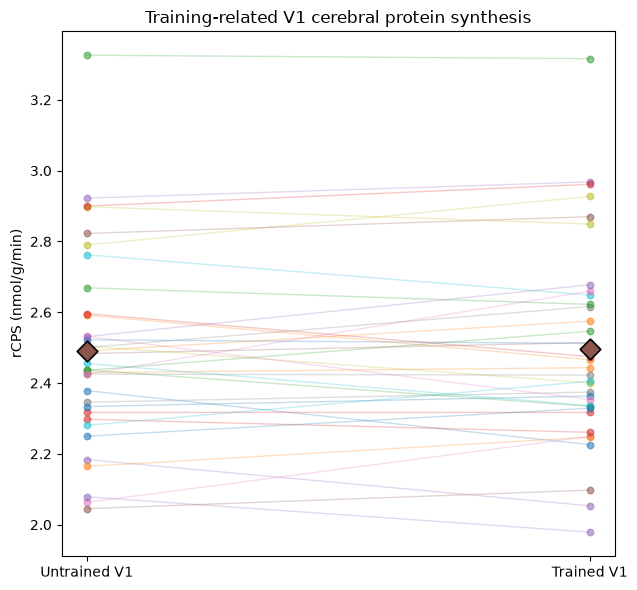

In [72]:
# Paired visualisation: each line is one participant.
fig, ax = plt.subplots(figsize=(6.5, 6))

for _, row in v1_valid.iterrows():
    ax.plot([0, 1], [row["untrained_v1"], row["trained_v1"]], alpha=0.25, linewidth=1)
    ax.scatter([0, 1], [row["untrained_v1"], row["trained_v1"]], s=22, alpha=0.55)

ax.scatter(
    [0, 1], [untrained.mean(), trained.mean()],
    marker="D", s=110, edgecolor="black", linewidth=1.2, zorder=5
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Untrained V1", "Trained V1"])
ax.set_ylabel("rCPS (nmol/g/min)")
ax.set_title("Training-related V1 cerebral protein synthesis")
plt.tight_layout()
plt.savefig(figures_dir / "trained_vs_untrained_v1.png", dpi=300, bbox_inches="tight")
plt.show()


The cohort-level trained–untrained contrast is intentionally interpreted as a molecular **training-related** measure rather than a direct behavioural measure of consolidation. A null trained-V1 effect does not demonstrate absence of consolidation; it indicates that this PET-derived molecular contrast did not show a detectable cohort-wide shift.


### 9.2 Does sleep amplify the trained–untrained V1 difference?

The key sleep-dependent consolidation test compares the participant-level trained–untrained V1 contrast between the Asleep and Awake groups. A larger positive contrast in the Asleep group would be consistent with greater post-training rCPS lateralisation associated with the sleep interval.


In [73]:
asleep_v1 = v1_valid.loc[v1_valid["condition"] == "Asleep", "difference"]
awake_v1 = v1_valid.loc[v1_valid["condition"] == "Awake", "difference"]

sleep_v1_t, sleep_v1_p = stats.ttest_ind(asleep_v1, awake_v1, equal_var=False)
mean_sleep_effect = asleep_v1.mean() - awake_v1.mean()

v_a = asleep_v1.var(ddof=1) / len(asleep_v1)
v_w = awake_v1.var(ddof=1) / len(awake_v1)
df_sleep_v1 = (v_a + v_w)**2 / (
    v_a**2 / (len(asleep_v1)-1) + v_w**2 / (len(awake_v1)-1)
)
se_sleep_v1 = np.sqrt(v_a + v_w)
tcrit = stats.t.ppf(0.975, df_sleep_v1)
ci_sleep_v1 = (
    mean_sleep_effect - tcrit * se_sleep_v1,
    mean_sleep_effect + tcrit * se_sleep_v1
)
pooled_sd = np.sqrt(
    ((len(asleep_v1)-1)*asleep_v1.var(ddof=1) + (len(awake_v1)-1)*awake_v1.var(ddof=1)) /
    (len(asleep_v1)+len(awake_v1)-2)
)
d_sleep_v1 = mean_sleep_effect / pooled_sd

print(f"Asleep trained-untrained difference: {asleep_v1.mean():.4f}")
print(f"Awake trained-untrained difference:  {awake_v1.mean():.4f}")
print(f"Asleep - Awake: {mean_sleep_effect:.4f}")
print(f"Welch t({df_sleep_v1:.2f}) = {sleep_v1_t:.3f}")
print(f"p = {sleep_v1_p:.4f}")
print(f"95% CI = [{ci_sleep_v1[0]:.4f}, {ci_sleep_v1[1]:.4f}]")
print(f"Cohen's d = {d_sleep_v1:.3f}")


Asleep trained-untrained difference: 0.0161
Awake trained-untrained difference:  -0.0049
Asleep - Awake: 0.0210
Welch t(32.98) = 0.591
p = 0.5583
95% CI = [-0.0513, 0.0934]
Cohen's d = 0.199


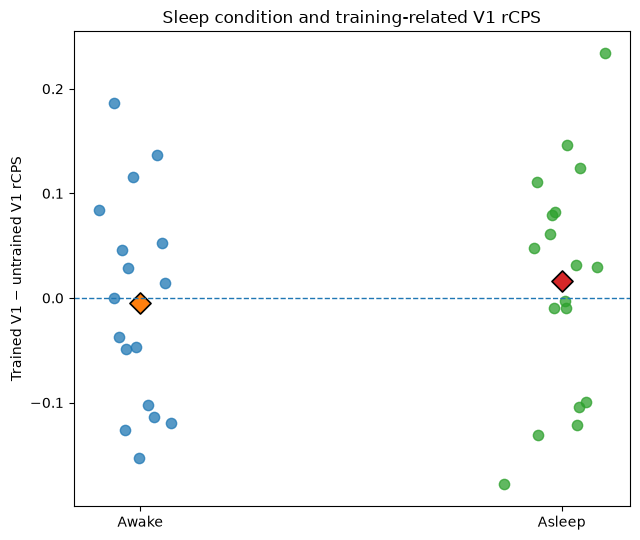

In [74]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

rng = np.random.default_rng(731)
for x, condition in enumerate(["Awake", "Asleep"]):
    vals = v1_valid.loc[v1_valid["condition"] == condition, "difference"]
    jitter = rng.normal(0, 0.045, len(vals))
    ax.scatter(np.full(len(vals), x) + jitter, vals, s=55, alpha=0.75)
    ax.scatter(x, vals.mean(), marker="D", s=115, edgecolor="black", linewidth=1.2)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Awake", "Asleep"])
ax.set_ylabel("Trained V1 − untrained V1 rCPS")
ax.set_title("Sleep condition and training-related V1 rCPS")
plt.tight_layout()
plt.savefig(figures_dir / "sleep_training_v1_difference.png", dpi=300, bbox_inches="tight")
plt.show()


### 9.3 Is sleep architecture related to the training-specific V1 contrast?

Within participants assigned to sleep, sleep-stage composition provides a more specific physiological measure than sleep-group assignment alone. This exploratory analysis tests whether the trained–untrained V1 rCPS difference is associated with the percentage of the sleep interval spent in N1, N2, N3, or REM sleep.

These analyses are treated as exploratory because of the modest number of sleeping participants and the interdependence of sleep-stage proportions. Particular attention is given to REM sleep as a biologically interesting component of post-training sleep, while effects across all available sleep stages are reported to avoid selective interpretation.

*Sleep-stage analyses require complete participant-level session metadata and are therefore performed only where the relevant source metadata are available.*

In [75]:
import urllib.request
from pathlib import Path

# All 35 participants already identified in our PET cohort
participants = sorted(surface_check["participant"].unique())

metadata_dir = data_dir / "session_metadata"
metadata_dir.mkdir(parents=True, exist_ok=True)

base_url = "https://openneuro.org/crn/datasets/ds004731/snapshots/1.0.0/files"

downloaded = []
failed = []

for participant in participants:
    filename = f"{participant}_sessions.tsv"
    url = f"{base_url}/{participant}:{filename}"
    out = metadata_dir / filename

    try:
        urllib.request.urlretrieve(url, out)
        downloaded.append(participant)
        print("✓", participant)
    except Exception as e:
        failed.append((participant, str(e)))
        print("✗", participant)

print("\nDownloaded:", len(downloaded))
print("Failed:", len(failed))

if failed:
    print("\nFailures:")
    for item in failed:
        print(item)

✓ sub-SM07
✓ sub-SM08
✓ sub-SM09
✓ sub-SM10
✓ sub-SM11
✓ sub-SM12
✓ sub-SM16
✓ sub-SM19
✓ sub-SM21
✓ sub-SM22
✓ sub-SM23
✓ sub-SM24
✓ sub-SM27
✓ sub-SM28
✓ sub-SM30
✓ sub-SM31
✓ sub-SM32
✓ sub-SM33
✓ sub-SM35
✓ sub-SM36
✓ sub-SM37
✓ sub-SM38
✓ sub-SM40
✓ sub-SM43
✓ sub-SM45
✓ sub-SM47
✓ sub-SM48
✓ sub-SM50
✓ sub-SM51
✓ sub-SM52
✓ sub-SM54
✓ sub-SM56
✓ sub-SM58
✓ sub-SM60
✓ sub-SM61

Downloaded: 35
Failed: 0


In [76]:
metadata_files = sorted(metadata_dir.glob("*_sessions.tsv"))

print("Session files:", len(metadata_files))

# Inspect one sleeping participant
test = pd.read_csv(
    metadata_dir / "sub-SM09_sessions.tsv",
    sep="\t"
)

print("\nColumns:")
print(test.columns.tolist())

display(test)

Session files: 35

Columns:
['session_id', 'age', 'weight', 'height', 'acq_time', 'percent_time_awake', 'percent_time_stage_1', 'percent_time_stage_2', 'percent_time_stage_3', 'percent_time_rem', 'trained_visual_field']


,session_id,age,weight,height,acq_time,percent_time_awake,percent_time_stage_1,percent_time_stage_2,percent_time_stage_3,percent_time_rem,trained_visual_field
0,ses-Asleep,24,74.9,0,2011-11-01T00:00:00,59,0,5,35,0,right


In [77]:
rows = []

for file in metadata_files:
    participant = file.name.replace("_sessions.tsv", "")
    df = pd.read_csv(file, sep="\t")

    if len(df) != 1:
        raise ValueError(
            f"{participant}: expected 1 session row, found {len(df)}"
        )

    row = df.iloc[0]

    rows.append({
        "participant": participant,
        "condition": row["session_id"].replace("ses-", ""),
        "trained_visual_field": row["trained_visual_field"],
        "percent_awake": row["percent_time_awake"],
        "stage_1": row["percent_time_stage_1"],
        "stage_2": row["percent_time_stage_2"],
        "stage_3": row["percent_time_stage_3"],
        "rem": row["percent_time_rem"],
    })

memory_meta = pd.DataFrame(rows).sort_values("participant").reset_index(drop=True)

print("Participants:", len(memory_meta))
print("\nCondition counts:")
print(memory_meta["condition"].value_counts())

print("\nTrained visual field:")
print(memory_meta["trained_visual_field"].value_counts())

print("\nMissing values:")
print(memory_meta.isna().sum())

display(memory_meta.head())

Participants: 35

Condition counts:
condition
Asleep    18
Awake     17
Name: count, dtype: int64

Trained visual field:
trained_visual_field
right    18
left     17
Name: count, dtype: int64

Missing values:
participant             0
condition               0
trained_visual_field    0
percent_awake           0
stage_1                 0
stage_2                 0
stage_3                 0
rem                     0
dtype: int64


,participant,condition,trained_visual_field,percent_awake,stage_1,stage_2,stage_3,rem
0,sub-SM07,Awake,right,98,2,0,0,0
1,sub-SM08,Awake,right,100,0,0,0,0
2,sub-SM09,Asleep,right,59,0,5,35,0
3,sub-SM10,Awake,left,99,1,0,0,0
4,sub-SM11,Asleep,right,17,3,5,76,0


In [78]:
metadata_path = data_dir / "memory_consolidation_metadata.csv"

memory_meta.to_csv(metadata_path, index=False)

print("Saved:", metadata_path)
print("Rows:", len(memory_meta))

Saved: C:\Users\asus\Downloads\PET_memory_consolidation_memory_focused_GitHub\data\memory_consolidation_metadata.csv
Rows: 35


In [79]:
# Add sleep architecture to participant-level V1 results
sleep_cols = [
    "participant",
    "percent_awake",
    "stage_1",
    "stage_2",
    "stage_3",
    "rem"
]

v1_sleep = v1_valid.merge(
    memory_meta[sleep_cols],
    on="participant",
    how="left",
    validate="one_to_one"
)

# Restrict sleep-architecture analyses to participants assigned to sleep
asleep_sleep = v1_sleep[
    v1_sleep["condition"] == "Asleep"
].copy()

print("V1 participants:", len(v1_sleep))
print("Asleep participants:", len(asleep_sleep))

print("\nMissing sleep metadata:")
print(
    asleep_sleep[
        ["percent_awake", "stage_1", "stage_2", "stage_3", "rem"]
    ].isna().sum()
)

display(
    asleep_sleep[
        [
            "participant",
            "difference",
            "percent_awake",
            "stage_1",
            "stage_2",
            "stage_3",
            "rem"
        ]
    ]
)

V1 participants: 35
Asleep participants: 18

Missing sleep metadata:
percent_awake    0
stage_1          0
stage_2          0
stage_3          0
rem              0
dtype: int64


,participant,difference,percent_awake,stage_1,stage_2,stage_3,rem
2,sub-SM09,0.110524,59,0,5,35,0
4,sub-SM11,-0.130715,17,3,5,76,0
5,sub-SM12,0.031169,19,23,19,38,0
8,sub-SM21,-0.103917,20,4,5,71,0
10,sub-SM23,0.029664,4,6,18,64,9
11,sub-SM24,0.082613,15,2,16,68,0
14,sub-SM30,-0.099556,9,1,34,51,6
16,sub-SM32,-0.178204,25,1,17,57,0
17,sub-SM33,-0.002768,0,3,29,68,0
20,sub-SM37,-0.009824,6,2,20,70,3


In [80]:
sleep_vars = ["percent_awake", "stage_1", "stage_2", "stage_3", "rem"]

sleep_summary = asleep_sleep[sleep_vars].describe().T

sleep_summary["n_zero"] = (
    asleep_sleep[sleep_vars] == 0
).sum()

sleep_summary["n_nonzero"] = (
    asleep_sleep[sleep_vars] > 0
).sum()

display(
    sleep_summary[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max",
         "n_zero", "n_nonzero"]
    ]
)

,count,mean,std,min,25%,50%,75%,max,n_zero,n_nonzero
percent_awake,18.0,16.611111,17.365073,0.0,4.50,12.0,19.75,60.0,1,17
stage_1,18.0,3.055556,5.395774,0.0,0.00,1.5,3.00,23.0,6,12
stage_2,18.0,16.611111,9.792788,0.0,8.25,16.5,24.50,34.0,1,17
stage_3,18.0,61.944444,14.746773,35.0,52.50,64.5,70.75,85.0,0,18
rem,18.0,2.055556,4.136953,0.0,0.00,0.0,2.25,15.0,13,5


In [81]:
sleep_stages = ["stage_1", "stage_2", "stage_3", "rem"]

results = []

for stage in sleep_stages:
    x = asleep_sleep[stage]
    y = asleep_sleep["difference"]

    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)

    results.append({
        "sleep_stage": stage,
        "n": len(x),
        "pearson_r": pearson.statistic,
        "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic,
        "spearman_p": spearman.pvalue,
        "n_nonzero": (x > 0).sum()
    })

sleep_stage_results = pd.DataFrame(results)

display(
    sleep_stage_results.round(4)
)

,sleep_stage,n,pearson_r,pearson_p,spearman_rho,spearman_p,n_nonzero
0,stage_1,18,0.0231,0.9274,-0.1014,0.6889,12
1,stage_2,18,0.0535,0.8331,0.0393,0.8768,17
2,stage_3,18,0.1207,0.6332,-0.0682,0.7880,18
3,rem,18,0.1494,0.5540,0.0744,0.7691,5


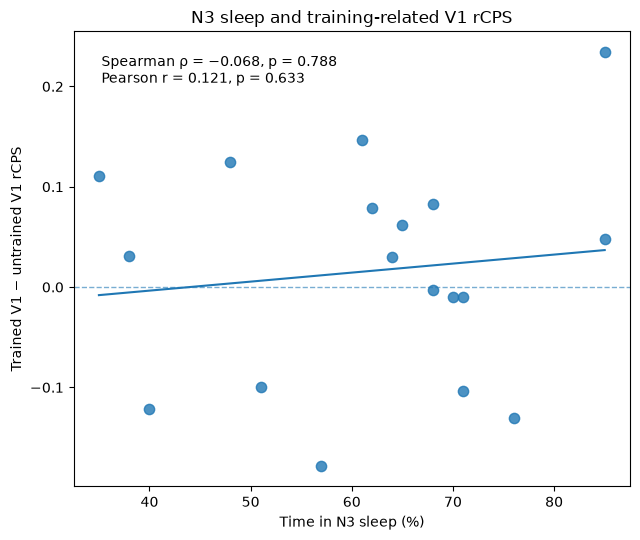

In [82]:
x = asleep_sleep["stage_3"]
y = asleep_sleep["difference"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))

ax.scatter(x, y, s=55, alpha=0.8)

# Descriptive linear trend
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, intercept + slope * x_line)

ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("Time in N3 sleep (%)")
ax.set_ylabel("Trained V1 − untrained V1 rCPS")
ax.set_title("N3 sleep and training-related V1 rCPS")

ax.text(
    0.05, 0.95,
    "Spearman ρ = −0.068, p = 0.788\n"
    "Pearson r = 0.121, p = 0.633",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "n3_training_v1_association.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
from statsmodels.stats.multitest import multipletests

_, sleep_stage_results["spearman_p_fdr"], _, _ = multipletests(
    sleep_stage_results["spearman_p"],
    method="fdr_bh"
)

sleep_stage_results["stage"] = sleep_stage_results["sleep_stage"].map({
    "stage_1": "N1",
    "stage_2": "N2",
    "stage_3": "N3",
    "rem": "REM"
})

display(
    sleep_stage_results[
        [
            "stage",
            "n",
            "n_nonzero",
            "spearman_rho",
            "spearman_p",
            "spearman_p_fdr",
            "pearson_r",
            "pearson_p"
        ]
    ].round(4)
)

,stage,n,n_nonzero,spearman_rho,spearman_p,spearman_p_fdr,pearson_r,pearson_p
0,N1,18,12,-0.1014,0.6889,0.8768,0.0231,0.9274
1,N2,18,17,0.0393,0.8768,0.8768,0.0535,0.8331
2,N3,18,18,-0.0682,0.7880,0.8768,0.1207,0.6332
3,REM,18,5,0.0744,0.7691,0.8768,0.1494,0.5540


## 9.4 Distributed cortical effects of sleep condition

The targeted V1 analyses test a spatially specific hypothesis, but experience-dependent molecular effects may not be restricted to primary visual cortex. To examine whether sleep condition is associated with a broader cortical pattern of rCPS, regional effects are estimated independently across the Destrieux parcellation using participant-level measurements that passed coverage QC.

### Memory-consolidation result

Across the full cohort, trained V1 and untrained V1 showed nearly identical mean rCPS (2.4971 vs 2.4912 nmol/g/min in the validated exploratory analysis; paired *t*(34) = 0.336, *p* = 0.739, Cohen's *d*z = 0.057). The trained–untrained difference was numerically more positive in the Asleep group (+0.0161 nmol/g/min) than in the Awake group (−0.0049 nmol/g/min), but the between-group contrast was small and uncertain (Welch *t* ≈ 0.59, *p* = 0.558, 95% CI [−0.0513, 0.0934], *d* ≈ 0.20). Within the 18 asleep participants, Stage 3 sleep was not associated with the V1 contrast (Pearson *r* = 0.121, *p* = 0.633; Spearman ρ = −0.068, *p* = 0.788).

Together, these targeted analyses do **not** provide detectable PET evidence that sleep amplified protein synthesis specifically in trained V1 in this sample. This is a null molecular result, not evidence that memory consolidation did not occur: behavioural improvement is not analysed here, and rCPS may reflect processes that are spatially distributed, temporally heterogeneous, or not captured by a simple hemispheric V1 contrast.


In [84]:
regional_effects = []

for (hemi, region), df in analysis_regions.groupby(
    ["hemisphere", "region"]
):

    asleep = df.loc[
        df["condition"] == "Asleep",
        "mean_rcps"
    ]

    awake = df.loc[
        df["condition"] == "Awake",
        "mean_rcps"
    ]

    # Require reasonable representation in both groups
    if len(asleep) >= 10 and len(awake) >= 10:

        test = stats.ttest_ind(
            asleep,
            awake,
            equal_var=False
        )

        regional_effects.append({
            "hemisphere": hemi,
            "region": region,
            "n_asleep": len(asleep),
            "n_awake": len(awake),
            "mean_asleep": asleep.mean(),
            "mean_awake": awake.mean(),
            "difference": asleep.mean() - awake.mean(),
            "t": test.statistic,
            "p": test.pvalue
        })

regional_effects = pd.DataFrame(regional_effects)

print("Regions tested:", len(regional_effects))

display(
    regional_effects
    .sort_values("difference", ascending=False)
    .head(10)
)

Regions tested: 147


,hemisphere,region,n_asleep,n_awake,mean_asleep,mean_awake,difference,t,p
73,left,S_temporal_transverse,18,17,2.177692,1.988168,0.189525,1.446941,0.157354
142,right,S_suborbital,17,17,1.883222,1.739350,0.143872,1.613792,0.117044
68,left,S_precentral-sup-part,18,17,1.871056,1.733701,0.137355,1.594013,0.121412
67,left,S_precentral-inf-part,18,17,1.959870,1.830891,0.128979,1.281011,0.211169
4,left,G_and_S_frontomargin,18,16,2.115549,1.994533,0.121017,1.444623,0.158772
87,right,G_front_inf-Orbital,17,16,2.030069,1.912523,0.117546,0.954925,0.348189
127,right,S_interm_prim-Jensen,18,17,2.075999,1.977992,0.098007,0.990512,0.330216
25,left,G_pariet_inf-Supramar,18,17,2.185958,2.089104,0.096854,1.050225,0.302059
104,right,G_subcallosal,14,12,1.729491,1.634501,0.094990,0.589068,0.561331
66,left,S_postcentral,18,17,1.863405,1.769239,0.094166,1.169155,0.252096


In [85]:
# Cohen's d for each regional Sleep–Wake comparison
def cohens_d_independent(x, y):
    nx, ny = len(x), len(y)

    pooled_sd = np.sqrt(
        ((nx - 1) * x.var(ddof=1) +
         (ny - 1) * y.var(ddof=1))
        / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_sd


effect_sizes = []

for _, row in regional_effects.iterrows():

    df = analysis_regions[
        (analysis_regions["hemisphere"] == row["hemisphere"]) &
        (analysis_regions["region"] == row["region"])
    ]

    asleep = df.loc[df["condition"] == "Asleep", "mean_rcps"]
    awake = df.loc[df["condition"] == "Awake", "mean_rcps"]

    effect_sizes.append(
        cohens_d_independent(asleep, awake)
    )

regional_effects["cohens_d"] = effect_sizes

# FDR correction across all regional tests
regional_effects["p_fdr"] = multipletests(
    regional_effects["p"],
    method="fdr_bh"
)[1]

regional_effects["fdr_significant"] = (
    regional_effects["p_fdr"] < 0.05
)

print(
    "Uncorrected p < .05:",
    (regional_effects["p"] < 0.05).sum()
)

print(
    "FDR significant:",
    regional_effects["fdr_significant"].sum()
)

display(
    regional_effects
    .sort_values("p")
    .head(15)
    .round(4)
)

Uncorrected p < .05: 0
FDR significant: 0


,hemisphere,region,n_asleep,n_awake,mean_asleep,mean_awake,difference,t,p,cohens_d,p_fdr,fdr_significant
142,right,S_suborbital,17,17,1.8832,1.7393,0.1439,1.6138,0.1170,0.5535,0.9709,False
68,left,S_precentral-sup-part,18,17,1.8711,1.7337,0.1374,1.5940,0.1214,0.5332,0.9709,False
73,left,S_temporal_transverse,18,17,2.1777,1.9882,0.1895,1.4469,0.1574,0.4889,0.9709,False
4,left,G_and_S_frontomargin,18,16,2.1155,1.9945,0.1210,1.4446,0.1588,0.4862,0.9709,False
67,left,S_precentral-inf-part,18,17,1.9599,1.8309,0.1290,1.2810,0.2112,0.4265,0.9709,False
141,right,S_precentral-sup-part,18,17,1.8136,1.7261,0.0874,1.2037,0.2383,0.4023,0.9709,False
144,right,S_temporal_inf,18,17,1.8679,1.7810,0.0869,1.1939,0.2411,0.4020,0.9709,False
31,left,G_subcallosal,17,16,1.5180,1.6415,-0.1235,-1.1912,0.2428,-0.4161,0.9709,False
108,right,G_temp_sup-Plan_tempo,18,17,2.0115,2.1186,-0.1071,-1.1751,0.2487,-0.3991,0.9709,False
66,left,S_postcentral,18,17,1.8634,1.7692,0.0942,1.1692,0.2521,0.3901,0.9709,False


In [86]:
all_regions = (
    cohort_regions[
        ["hemisphere", "region"]
    ]
    .drop_duplicates()
)

tested_regions = regional_effects[
    ["hemisphere", "region"]
]

excluded_region = (
    all_regions
    .merge(
        tested_regions,
        on=["hemisphere", "region"],
        how="left",
        indicator=True
    )
    .query('_merge == "left_only"')
    [["hemisphere", "region"]]
)

print("Excluded regions:")
display(excluded_region)

Excluded regions:


,hemisphere,region
104,right,G_rectus


In [87]:
# Vertex-wise Cohen's d maps
lh_effect = np.full(len(fsavg_lh_labels), np.nan)
rh_effect = np.full(len(fsavg_rh_labels), np.nan)

# Ensure annotation names are strings
lh_names_clean = [
    n.decode("utf-8") if isinstance(n, bytes) else str(n)
    for n in fsavg_lh_names
]

rh_names_clean = [
    n.decode("utf-8") if isinstance(n, bytes) else str(n)
    for n in fsavg_rh_names
]

unmatched = []

for _, row in regional_effects.iterrows():

    hemi = row["hemisphere"]
    region = row["region"]
    effect = row["cohens_d"]

    if hemi == "left":
        if region in lh_names_clean:
            label_index = lh_names_clean.index(region)
            lh_effect[fsavg_lh_labels == label_index] = effect
        else:
            unmatched.append(("left", region))

    elif hemi == "right":
        if region in rh_names_clean:
            label_index = rh_names_clean.index(region)
            rh_effect[fsavg_rh_labels == label_index] = effect
        else:
            unmatched.append(("right", region))

print("LH mapped vertices:", np.isfinite(lh_effect).sum())
print("RH mapped vertices:", np.isfinite(rh_effect).sum())

print(
    "Effect range:",
    min(np.nanmin(lh_effect), np.nanmin(rh_effect)),
    "to",
    max(np.nanmax(lh_effect), np.nanmax(rh_effect))
)

print("Unmatched regions:", unmatched)

LH mapped vertices: 149955
RH mapped vertices: 148994
Effect range: -0.4161081910133362 to 0.5535260438919067
Unmatched regions: []


In [88]:
from nilearn import datasets, plotting

# Fetch standard fsaverage surface geometry
fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage")

print("Left inflated:", fsaverage.infl_left)
print("Right inflated:", fsaverage.infl_right)
print("Left sulc:", fsaverage.sulc_left)
print("Right sulc:", fsaverage.sulc_right)

[fetch_surf_fsaverage] Dataset directory found: C:\Users\asus\nilearn_data\fsaverage
Left inflated: C:\Users\asus\nilearn_data\fsaverage\infl_left.gii.gz
Right inflated: C:\Users\asus\nilearn_data\fsaverage\infl_right.gii.gz
Left sulc: C:\Users\asus\nilearn_data\fsaverage\sulc_left.gii.gz
Right sulc: C:\Users\asus\nilearn_data\fsaverage\sulc_right.gii.gz


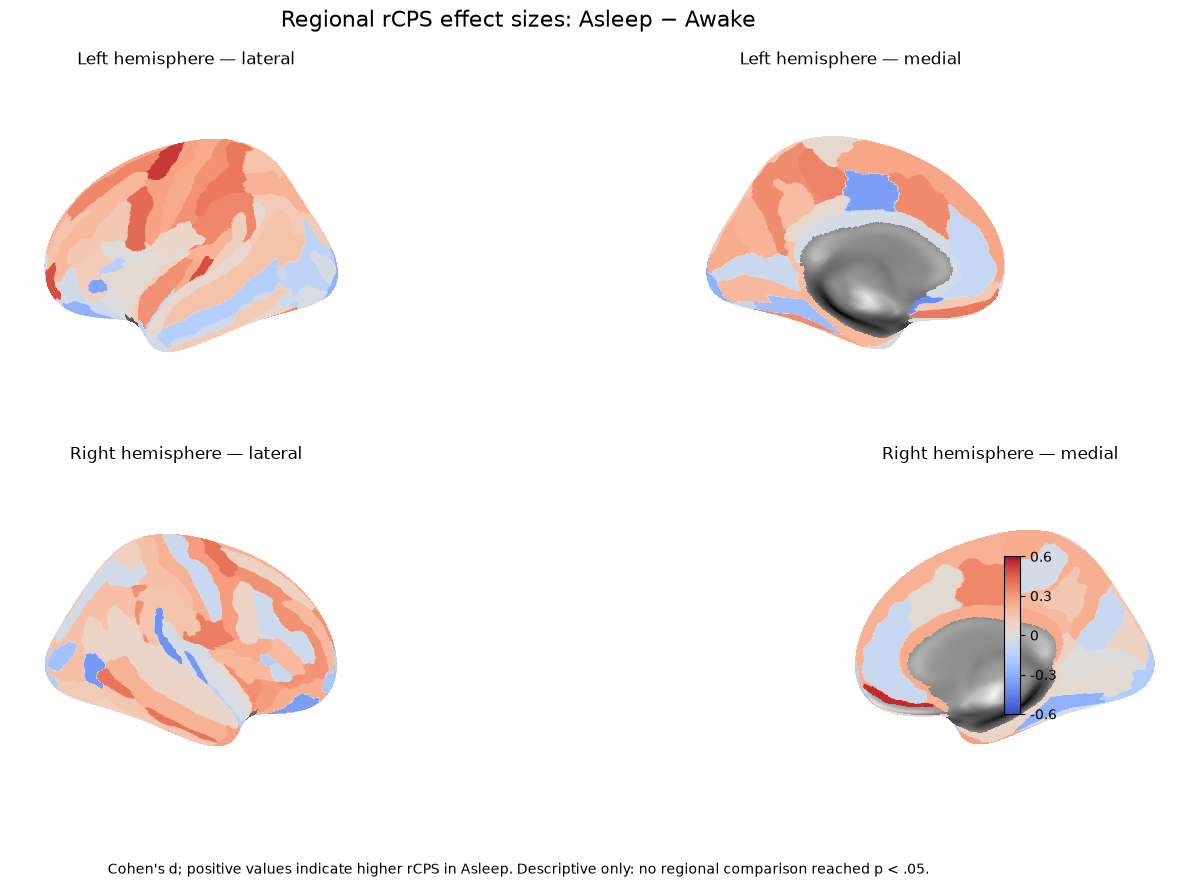

In [89]:
# Descriptive cortical effect-size map:
# positive d = higher rCPS in Asleep
# negative d = higher rCPS in Awake

vmax = 0.6

fig = plt.figure(figsize=(14, 9))

views = [
    ("left",  "lateral", fsaverage.infl_left,  fsaverage.sulc_left,  lh_effect),
    ("left",  "medial",  fsaverage.infl_left,  fsaverage.sulc_left,  lh_effect),
    ("right", "lateral", fsaverage.infl_right, fsaverage.sulc_right, rh_effect),
    ("right", "medial",  fsaverage.infl_right, fsaverage.sulc_right, rh_effect),
]

for i, (hemi, view, mesh, sulc, effect) in enumerate(views, 1):

    ax = fig.add_subplot(2, 2, i, projection="3d")

    plotting.plot_surf_stat_map(
        mesh,
        effect,
        hemi=hemi,
        view=view,
        bg_map=sulc,
        cmap="coolwarm",
        symmetric_cbar=True,
        vmin=-vmax,
        vmax=vmax,
        colorbar=(i == 4),
        axes=ax,
        title=f"{hemi.capitalize()} hemisphere — {view}"
    )

fig.suptitle(
    "Regional rCPS effect sizes: Asleep − Awake",
    fontsize=16,
    y=0.98
)

fig.text(
    0.5, 0.02,
    "Cohen's d; positive values indicate higher rCPS in Asleep. "
    "Descriptive only: no regional comparison reached p < .05.",
    ha="center",
    fontsize=10
)

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    bottom=0.08,
    top=0.91,
    wspace=0.02,
    hspace=0.12
)

plt.savefig(
    figures_dir / "cortical_sleep_wake_cohens_d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Summary and interpretation

### What was tested

This project asked whether [¹¹C]leucine PET-derived cerebral protein synthesis contains a molecular signature consistent with sleep-dependent consolidation after visual training. The analysis combined a broad cortical sleep/wake comparison with a targeted trained-versus-untrained V1 analysis, then related the V1 contrast to sleep condition and sleep-stage composition, with N1, N2, N3 and REM examined exploratorily and N3 as the principal continuous sleep-stage measure.

### Main findings

Following surface-space validation and Destrieux parcellation, 5,180 hemisphere-specific regional measurements were extracted across 35 participants (17 Awake, 18 Asleep); 5,062 measurements (97.7%) passed the ≥80% coverage criterion. Mean cortical rCPS was similar between the Asleep and Awake groups (1.933 ± 0.237 vs 1.909 ± 0.168 nmol/g/min; Δ = 0.024, 95% CI [−0.118, 0.165], Cohen's *d* = 0.114; Welch *t*(30.67) = 0.341, *p* = 0.735).

At the whole-cortex level, regional mapping showed heterogeneous Asleep–Awake differences. Although 101/148 hemisphere-specific parcels showed numerically higher mean rCPS in the Asleep group, participant-label permutation indicated that this cortex-wide directional predominance was not unusual under random group reassignment (p = 0.765).

The memory-consolidation-focused V1 analysis likewise found no detectable cohort-wide training-specific rCPS effect: trained and untrained V1 showed nearly identical mean rCPS (2.4971 vs 2.4912 nmol/g/min; paired t(34) = 0.336, p = 0.739, Cohen's d = 0.057). The trained–untrained contrast was numerically more positive in Asleep (+0.0161 nmol/g/min) than Awake participants (−0.0049 nmol/g/min), but this sleep-related difference was not statistically supported (Welch p = 0.558). Among sleepers, N3 was not associated with the trained–untrained V1 contrast (Pearson r = 0.121, p = 0.633; Spearman ρ = −0.068, p = 0.788), and exploratory analyses of N1, N2, N3 and REM similarly showed no detectable associations after FDR correction (all adjusted p ≈ 0.877). REM inference was limited because only 5/18 sleepers exhibited non-zero REM during the measured interval.

An exploratory region-wise analysis examined whether sleep–wake differences were spatially distributed across the cortex. Of 148 hemisphere-specific Destrieux parcels, 147 retained sufficient QC-passing observations for comparison; right G_rectus was excluded because it did not meet the minimum representation criterion. No regional comparison reached nominal significance (all p ≥ 0.117), and consequently none survived FDR correction. Estimated regional effect sizes nevertheless showed spatial heterogeneity (Cohen's d range: −0.416 to 0.554), which was visualised descriptively across the cortical surface. These spatial variations are treated as effect-size patterns rather than evidence for region-specific sleep effects.

### Interpretation

The analyses therefore do not show a large global cortical difference in rCPS associated with the sleep condition, nor a detectable sleep-related increase specifically in trained V1. Importantly, these null PET findings should not be interpreted as evidence that memory consolidation was absent. The notebook does not model behavioural memory performance directly, and protein-synthesis processes relevant to consolidation may be subtle, temporally specific, distributed across networks, or poorly represented by a single trained-versus-untrained V1 contrast.


### Computational outcome

Independently of the biological null result, the project demonstrates an end-to-end Python neuroimaging workflow: dynamic PET inspection, NIfTI handling, quantitative rCPS visualisation, FreeSurfer/fsaverage surface processing, atlas compatibility checks, Destrieux parcellation, coverage QC, cohort-level aggregation, effect-size estimation and cortical surface mapping, FDR correction, participant-level permutation testing, and hypothesis-driven V1 and sleep-stage analyses. The notebook is designed as a reproducible GitHub portfolio project and as a foundation for future work incorporating behavioural memory outcomes.
